In [1]:
import os
import shutil
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.layers import Conv2D, MaxPooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

In [2]:
def get_valid(file_path):
    correct_files = []
    for name in os.listdir(file_path):
        try:
            img = Image.open(file_path + "/" + name)
            correct_files.append(name)
        except UnidentifiedImageError:
            pass
    return correct_files

In [3]:
local_zip = 'C:/Users/abram/Desktop/Kodilla/learning-git-task/19.Sieci_konwulcyjne/kagglecatsanddogs_5340.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()
classes = ['Cat', 'Dog']
original_cat_path = '/tmp/PetImages/Cat'
original_dog_path = '/tmp/PetImages/Dog'
original_cat = get_valid(original_cat_path)
original_dog = get_valid(original_dog_path)
random.seed(101)

random.shuffle(original_cat)
random.shuffle(original_dog)
size = min(len(original_cat), len(original_dog))
train_size = int(np.floor(0.7 * size))

valid_size = int(np.floor(0.2 * size))
test_size = size - train_size - valid_size
base_directory = 'dataset'
os.mkdir(base_directory)
type_datasets = ['train', 'valid', 'test']
directories = {}

for type_dataset in type_datasets:
    directory = os.path.join(base_directory, type_dataset)
    os.mkdir(directory)
    for name_class in classes:
        animal = os.path.join(directory, name_class)
        os.mkdir(animal)
        directories[f'{type_dataset}_{name_class}'] = animal+'/'
index = 0

for name_cat, name_dog in zip(original_cat, original_dog):
        if index <= train_size:
            type_of_dataset = 'train'
        elif train_size < index <= (train_size + valid_size):
            type_of_dataset = 'valid'
        elif (train_size + valid_size) < index <= (train_size + valid_size + test_size):
            type_of_dataset = 'test'
        shutil.copyfile(src=(original_cat_path + '/' +name_cat), dst=(directories[f'{type_of_dataset}_Cat']+name_cat))
        shutil.copyfile(src=(original_dog_path + '/' + name_dog), dst=(directories[f'{type_of_dataset}_Dog']+name_dog))
        index += 1

print(f'Dog - train: {len(os.listdir(directories["train_Dog"]))}\tCat - train: {len(os.listdir(directories["train_Cat"]))}')
print(f'Dog - valid: {len(os.listdir(directories["valid_Dog"]))}\tCat - valid: {len(os.listdir(directories["valid_Cat"]))}')
print(f'Dog - test:  {len(os.listdir(directories["test_Dog"]))}\tCat - test:  {len(os.listdir(directories["test_Cat"]))}')

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Dog - train: 8750	Cat - train: 8750
Dog - valid: 2499	Cat - valid: 2499
Dog - test:  1250	Cat - test:  1250


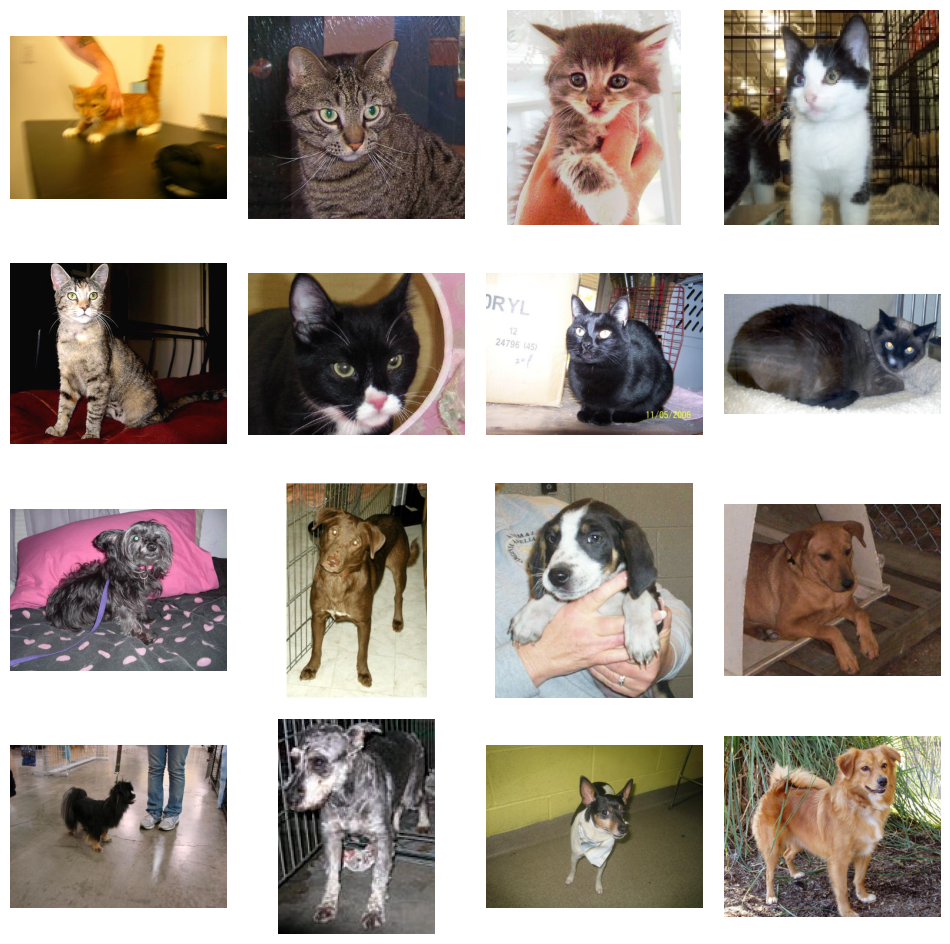

In [4]:
fig = plt.figure(figsize = (12, 12))
fig.subplots_adjust(hspace=0.1, wspace=0.1)
for i, element in enumerate(os.listdir(os.path.join(directories["train_Cat"]))[:8]):
    ax = fig.add_subplot(4, 4, i+1)
    img = Image.open(directories["train_Cat"]+element)
    ax.imshow(img)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

for i, element in enumerate(os.listdir(os.path.join(directories["train_Dog"]))[:8]):
    ax = fig.add_subplot(4, 4, i+9)
    img = Image.open(directories["train_Dog"]+element)
    ax.imshow(img)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [5]:
img_width, img_height = 150, 150
train_data_dir = 'dataset/train/'
validation_data_dir = 'dataset/valid/'
epochs = 1000
batch_size = 64
steps_per_epoch = train_size // batch_size
validation_steps = valid_size // batch_size
patience = 5
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_data_dir,
                                                    target_size=(img_height, img_width),
                                                    batch_size=batch_size, class_mode='binary')
validation_generator = test_datagen.flow_from_directory(validation_data_dir,
                                                        target_size=(img_height, img_width),
                                                        batch_size=batch_size, class_mode='binary', shuffle=False,)
train_datagen_augmentation = ImageDataGenerator(rescale=1./255,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   rotation_range=30,
                                   horizontal_flip=True)
train_generator_augmentation = train_datagen_augmentation.flow_from_directory(train_data_dir,
                                                    target_size=(img_height, img_width),
                                                    batch_size=batch_size, class_mode='binary')


models = []
os.mkdir("history")
os.mkdir("charts")

Found 17500 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.
Found 17500 images belonging to 2 classes.


In [6]:
model_baseline = Sequential()
model_baseline.add(Flatten(input_shape=(150, 150, 3)))
model_baseline.add(Dense(units=1, activation='sigmoid'))
model_baseline.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(learning_rate=1e-4),
                       metrics=['accuracy'])
model_baseline.summary()
models.append("baseline")

es = EarlyStopping(patience=patience, monitor='val_accuracy', restore_best_weights=True)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 67500)             0         
                                                                 
 dense (Dense)               (None, 1)                 67501     
                                                                 
Total params: 67501 (263.68 KB)
Trainable params: 67501 (263.68 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
history_baseline = model_baseline.fit(train_generator,
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                callbacks=[es])
history_baseline_df = pd.DataFrame(history_baseline.history)
history_baseline_csv_file = 'history/history_baseline.csv'

with open(history_baseline_csv_file, mode='w') as f:
    history_baseline_df.to_csv(f)

Epoch 1/1000


274/274 [==============================] - 25s 89ms/step - loss: 0.9715 - accuracy: 0.5038 - val_loss: 0.8931 - val_accuracy: 0.5034
Epoch 2/1000
274/274 [==============================] - 24s 88ms/step - loss: 0.9396 - accuracy: 0.5145 - val_loss: 0.9966 - val_accuracy: 0.5020
Epoch 3/1000
274/274 [==============================] - 24s 86ms/step - loss: 0.9073 - accuracy: 0.5331 - val_loss: 0.6736 - val_accuracy: 0.5934
Epoch 4/1000
274/274 [==============================] - 24s 88ms/step - loss: 0.9088 - accuracy: 0.5285 - val_loss: 0.8259 - val_accuracy: 0.5230
Epoch 5/1000
274/274 [==============================] - 24s 89ms/step - loss: 0.9081 - accuracy: 0.5318 - val_loss: 0.7559 - val_accuracy: 0.5422
Epoch 6/1000
274/274 [==============================] - 24s 89ms/step - loss: 0.9068 - accuracy: 0.5304 - val_loss: 0.9006 - val_accuracy: 0.5230
Epoch 7/1000
274/274 [==============================] - 24s 89ms/step - loss: 0.8908 - accuracy: 0.5463 - val_loss: 0.7197

In [8]:
def plot_models():    
    max_index = 0
    min_accuracy = 1
    max_loss = 0
    colors = plt.cm.rainbow(np.linspace(0, 1, len(models)))

    for model in models:
        df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
        df.index += 1
        if max_index < max(df.index):
            max_index = max(df.index)
        if min_accuracy > min(df[['accuracy', 'val_accuracy']].min()):
            min_accuracy = min(df[['accuracy', 'val_accuracy']].min())
        if max_loss < max(df[['loss', 'val_loss']].max()):
            max_loss = max(df[['loss', 'val_loss']].max())

    for model in models:
        df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
        df.index += 1
        fig = plt.figure(figsize=(16,12))
        ax = fig.add_subplot(211)
        ax.plot(df['accuracy'], "bp--")
        ax.plot(df['val_accuracy'], "rp--")
        ax.set_title(f'Model {model} Accuracy', fontsize=20)
        ax.set_ylabel('Accuracy', fontsize=15)
        ax.set_xlabel('Epoch', fontsize=15)
        ax.set_xlim([1, max_index])
        ax.set_ylim([min_accuracy, 1])

        for milestone in (0.7, 0.8, 0.9, 0.95):
            ax.axhline(milestone, color="k", linestyle="--")
            try:
                if min(df[df['val_accuracy'] >= milestone].index) > 1:
                    plt.axvline(min(df[df['val_accuracy'] >= milestone].index), color="g", linestyle="--")
                    ax.text(min(df[df['val_accuracy'] >= milestone].index)+0.6, min_accuracy+0.02,
                            f'Epoch: {min(df[df["val_accuracy"] >= milestone].index)}', rotation=90)
            except:
                pass

        plt.legend(['Training', 'Validation'], loc='lower right')
        ax = fig.add_subplot(212)
        ax.plot(df['loss'], "bp--")
        ax.plot(df['val_loss'], "rp--")
        ax.set_title(f'Model {model} Loss', fontsize=20)
        ax.set_ylabel('Loss', fontsize=15)
        ax.set_xlabel('Epoch', fontsize=15)
        ax.set_xlim([1, max_index])
        ax.set_ylim([0, max_loss])
        ax.legend(['Training', 'Validation'], loc='upper right')
        plt.tight_layout()
        plt.savefig(f'charts/train_history_{model}.png', transparent=True, dpi=600)
        plt.show()

    fig = plt.figure(figsize=(16,12))
    ax = fig.add_subplot(211)
    for model, color in zip(models, colors):
        df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
        df.index += 1
        ax.plot(df['val_accuracy'], label=f'Model {model}', color=color, linewidth=3)
        ax.axhline(df['val_accuracy'].max(), color=color, linestyle="dotted", linewidth=4)

    ax.set_title(f'Accuracy', fontsize=20)
    ax.set_ylabel('Accuracy', fontsize=15)
    ax.set_xlabel('Epoch', fontsize=15)
    ax.set_xlim([1, max_index])
    ax.set_ylim([min_accuracy, 1])
    for milestone in (0.7, 0.8, 0.9, 0.95):
        ax.axhline(milestone, color="k", linestyle="--")
    plt.legend(loc='lower right')
    ax = fig.add_subplot(212)
    for model, color in zip(models, colors):
        df = pd.read_csv(f'history/history_{model}.csv', index_col=0)
        df.index += 1
        ax.plot(df['val_loss'], label=f'Model {model}', color=color, linewidth=3)
        ax.axhline(df['val_loss'].min(), color=color, linestyle="dotted", linewidth=4)
    ax.set_title(f'Loss', fontsize=20)
    ax.set_ylabel('Loss', fontsize=15)
    ax.set_xlabel('Epoch', fontsize=15)
    ax.set_xlim([1, max_index])
    ax.set_ylim([0, max_loss])
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig(f'charts/train_history_of_each_model.png', transparent=True, dpi=600)
    plt.show()

In [9]:
model_simple_1 = Sequential()
model_simple_1.add(Conv2D(filters=10, kernel_size=(3, 3), activation='relu', input_shape=(150, 150, 3)))
model_simple_1.add(MaxPooling2D(2, 2))
model_simple_1.add(Flatten())
model_simple_1.add(Dense(units=1, activation='sigmoid'))
model_simple_1.compile(loss='binary_crossentropy',
                       optimizer='adam',
                       metrics=['accuracy'])
model_simple_1.summary()
models.append("simple_1")



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 148, 148, 10)      280       
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 10)        0         
 D)                                                              
                                                                 
 flatten_1 (Flatten)         (None, 54760)             0         
                                                                 
 dense_1 (Dense)             (None, 1)                 54761     
                                                                 
Total params: 55041 (215.00 KB)
Trainable params: 55041 (215.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [10]:
history_simple_1 = model_simple_1.fit(train_generator,
                                                
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                
                                                callbacks=[es])

history_simple_1_df = pd.DataFrame(history_simple_1.history)
history_simple_1_csv_file = 'history/history_simple_1.csv'

with open(history_simple_1_csv_file, mode='w') as f:
    history_simple_1_df.to_csv(f)

Epoch 1/1000
274/274 [==============================] - 27s 97ms/step - loss: 0.6840 - accuracy: 0.6240 - val_loss: 0.6237 - val_accuracy: 0.6527
Epoch 2/1000
274/274 [==============================] - 26s 95ms/step - loss: 0.5821 - accuracy: 0.6925 - val_loss: 0.5874 - val_accuracy: 0.6957
Epoch 3/1000
274/274 [==============================] - 26s 93ms/step - loss: 0.5283 - accuracy: 0.7407 - val_loss: 0.5712 - val_accuracy: 0.7167
Epoch 4/1000
274/274 [==============================] - 25s 93ms/step - loss: 0.4809 - accuracy: 0.7717 - val_loss: 0.5709 - val_accuracy: 0.7231
Epoch 5/1000
274/274 [==============================] - 25s 92ms/step - loss: 0.4409 - accuracy: 0.7991 - val_loss: 0.5540 - val_accuracy: 0.7319
Epoch 6/1000
274/274 [==============================] - 26s 94ms/step - loss: 0.4116 - accuracy: 0.8134 - val_loss: 0.5616 - val_accuracy: 0.7359
Epoch 7/1000
274/274 [==============================] - 25s 92ms/step - loss: 0.3730 - accuracy: 0.8400 - val_loss: 0.5761 -

In [11]:
model_simple_2 = Sequential()
model_simple_2.add(Conv2D(filters=10, kernel_size=(3,3), padding='same', activation='relu', input_shape=(150,150,3)))
model_simple_2.add(MaxPooling2D(2,2))
model_simple_2.add(Flatten())
model_simple_2.add(Dense(units=1,activation='sigmoid'))
model_simple_2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_simple_2.summary()
models.append('simple_2')


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 150, 150, 10)      280       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 75, 75, 10)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 56250)             0         
                                                                 
 dense_2 (Dense)             (None, 1)                 56251     
                                                                 
Total params: 56531 (220.82 KB)
Trainable params: 56531 (220.82 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
history_simple_2 = model_simple_2.fit(train_generator,
                                                
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                
                                                callbacks=[es])
history_simple_2_df = pd.DataFrame(history_simple_2.history)
history_simple_2_csv_file = 'history/history_simple_2.csv'

with open(history_simple_2_csv_file, mode='w') as f:
    history_simple_2_df.to_csv(f)

Epoch 1/1000
274/274 [==============================] - 28s 101ms/step - loss: 0.6734 - accuracy: 0.6193 - val_loss: 0.6118 - val_accuracy: 0.6633
Epoch 2/1000
274/274 [==============================] - 25s 93ms/step - loss: 0.5448 - accuracy: 0.7247 - val_loss: 0.5711 - val_accuracy: 0.7145
Epoch 3/1000
274/274 [==============================] - 26s 93ms/step - loss: 0.4890 - accuracy: 0.7691 - val_loss: 0.5675 - val_accuracy: 0.7235
Epoch 4/1000
274/274 [==============================] - 25s 92ms/step - loss: 0.4472 - accuracy: 0.7961 - val_loss: 0.5575 - val_accuracy: 0.7275
Epoch 5/1000
274/274 [==============================] - 25s 92ms/step - loss: 0.4105 - accuracy: 0.8197 - val_loss: 0.5639 - val_accuracy: 0.7233
Epoch 6/1000
274/274 [==============================] - 25s 92ms/step - loss: 0.3721 - accuracy: 0.8435 - val_loss: 0.5816 - val_accuracy: 0.7195
Epoch 7/1000
274/274 [==============================] - 26s 94ms/step - loss: 0.3417 - accuracy: 0.8597 - val_loss: 0.6065 

In [13]:
model_1 = Sequential()

# Block 1
model_1.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_1.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_1.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_1.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_1.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Flatten())
model_1.add(Dense(256, activation='relu'))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(units=1, activation='sigmoid'))
model_1.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_1.summary()
models.append("model_1")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 150, 150, 16)      448       
                                                                 
 conv2d_3 (Conv2D)           (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 75, 75, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 75, 75, 32)        4640      
                                                                 
 conv2d_5 (Conv2D)           (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 37, 37, 32)        0         
 g2D)                                                 

In [14]:
model_2 = Sequential()

# Block 1
model_2.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_2.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_2.add(MaxPooling2D(pool_size=(2, 2)))
model_2.add(Flatten())
model_2.add(Dropout(0.5))
model_2.add(Dense(256, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dense(units=1, activation='sigmoid'))
model_2.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_2.summary()
models.append("model_2")

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 conv2d_11 (Conv2D)          (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 75, 75, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_12 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 conv2d_13 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_7 (MaxPoolin  (None, 37, 37, 32)        0         
 g2D)                                                 

In [15]:
history_model_1 = model_1.fit(train_generator,
                                                
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                
                                                callbacks=[es])
history_model_1_df = pd.DataFrame(history_model_1.history)
history_model_1_csv_file = 'history/history_model_1.csv'

with open(history_model_1_csv_file, mode='w') as f:
    history_model_1_df.to_csv(f)

Epoch 1/1000
274/274 [==============================] - 86s 310ms/step - loss: 0.6912 - accuracy: 0.5367 - val_loss: 0.6927 - val_accuracy: 0.5102
Epoch 2/1000
274/274 [==============================] - 93s 338ms/step - loss: 0.6449 - accuracy: 0.6172 - val_loss: 0.5893 - val_accuracy: 0.6887
Epoch 3/1000
274/274 [==============================] - 91s 331ms/step - loss: 0.5783 - accuracy: 0.6925 - val_loss: 0.5309 - val_accuracy: 0.7341
Epoch 4/1000
274/274 [==============================] - 93s 340ms/step - loss: 0.5248 - accuracy: 0.7356 - val_loss: 0.4657 - val_accuracy: 0.7695
Epoch 5/1000
274/274 [==============================] - 95s 346ms/step - loss: 0.4466 - accuracy: 0.7892 - val_loss: 0.4142 - val_accuracy: 0.8129
Epoch 6/1000
274/274 [==============================] - 94s 344ms/step - loss: 0.3710 - accuracy: 0.8311 - val_loss: 0.3452 - val_accuracy: 0.8517
Epoch 7/1000
274/274 [==============================] - 95s 348ms/step - loss: 0.3101 - accuracy: 0.8634 - val_loss: 0

In [16]:
history_model_2 = model_2.fit(train_generator,
                                                
                                                epochs=epochs,
                                                validation_data=validation_generator,
                                                
                                                callbacks=[es])
history_model_2_df = pd.DataFrame(history_model_2.history)
history_model_2_csv_file = 'history/history_model_2.csv'

with open(history_model_2_csv_file, mode='w') as f:
    history_model_2_df.to_csv(f)

Epoch 1/1000
274/274 [==============================] - 89s 320ms/step - loss: 0.6933 - accuracy: 0.5198 - val_loss: 0.7084 - val_accuracy: 0.5012
Epoch 2/1000
274/274 [==============================] - 86s 314ms/step - loss: 0.6576 - accuracy: 0.6138 - val_loss: 0.6206 - val_accuracy: 0.6519
Epoch 3/1000
274/274 [==============================] - 86s 313ms/step - loss: 0.5834 - accuracy: 0.6907 - val_loss: 0.5745 - val_accuracy: 0.6983
Epoch 4/1000
274/274 [==============================] - 89s 325ms/step - loss: 0.5382 - accuracy: 0.7259 - val_loss: 0.4907 - val_accuracy: 0.7755
Epoch 5/1000
274/274 [==============================] - 88s 321ms/step - loss: 0.4877 - accuracy: 0.7676 - val_loss: 0.4589 - val_accuracy: 0.7767
Epoch 6/1000
274/274 [==============================] - 88s 321ms/step - loss: 0.4284 - accuracy: 0.8011 - val_loss: 0.4251 - val_accuracy: 0.8061
Epoch 7/1000
274/274 [==============================] - 88s 322ms/step - loss: 0.3757 - accuracy: 0.8301 - val_loss: 0

In [21]:
model_3 = Sequential()

# Block 1
model_3.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_3.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_3.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_3.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_3.add(MaxPooling2D(pool_size=(2, 2)))
model_3.add(Flatten())
model_3.add(Dropout(0.5))
model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(0.5))
model_3.add(Dense(128, activation='relu'))
model_3.add(Dense(units=1, activation='sigmoid'))
model_3.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-3),
                       metrics=['accuracy'])
model_3.summary()
models.append("model_3")

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_26 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 conv2d_27 (Conv2D)          (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_14 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_28 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 conv2d_29 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_15 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                                

In [22]:
history_model_3 = model_3.fit(train_generator_augmentation,
                                        steps_per_epoch=steps_per_epoch,
                                        epochs=epochs,
                                        validation_data=validation_generator,
                                        validation_steps=validation_steps,
                                        callbacks=[es])

history_model_3_df = pd.DataFrame(history_model_3.history)
history_model_3_csv_file = 'history/history_model_3.csv'
with open(history_model_3_csv_file, mode='w') as f:
    history_model_3_df.to_csv(f)

Epoch 1/1000
136/136 [==============================] - 53s 384ms/step - loss: 0.6942 - accuracy: 0.4979 - val_loss: 0.6453 - val_accuracy: 1.0000
Epoch 2/1000
136/136 [==============================] - 53s 389ms/step - loss: 0.6934 - accuracy: 0.5149 - val_loss: 0.6433 - val_accuracy: 0.9860
Epoch 3/1000
136/136 [==============================] - 53s 386ms/step - loss: 0.6878 - accuracy: 0.5571 - val_loss: 0.6926 - val_accuracy: 0.5256
Epoch 4/1000
136/136 [==============================] - 54s 395ms/step - loss: 0.6763 - accuracy: 0.5929 - val_loss: 0.7135 - val_accuracy: 0.6034
Epoch 5/1000
136/136 [==============================] - 53s 392ms/step - loss: 0.6605 - accuracy: 0.6020 - val_loss: 0.7950 - val_accuracy: 0.5685
Epoch 6/1000
136/136 [==============================] - 53s 389ms/step - loss: 0.6413 - accuracy: 0.6309 - val_loss: 0.6444 - val_accuracy: 0.5713


In [23]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

vgg_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,)

vgg_validation_datagen = ImageDataGenerator(preprocessing_function=preprocess_input,)

vgg_train_generator = vgg_train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True,
)

vgg_validation_generator = vgg_validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
)

vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
vgg16.trainable = True

set_trainable = False
for layer in vgg16.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

for layer in vgg16.layers:
    print(f'layer_name: {layer.name:13} trainable: {layer.trainable}')

model_4 = Sequential()
model_4.add(vgg16)
model_4.add(Flatten())
model_4.add(Dropout(0.5))
model_4.add(Dense(256, activation='relu'))
model_4.add(Dropout(0.5))
model_4.add(Dense(128, activation='relu'))
model_4.add(Dense(units=1, activation='sigmoid'))
model_4.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_4.summary()
models.append("model_4")

history_model_4 = model_4.fit(vgg_train_generator,
                                        
                                        epochs=epochs,
                                        validation_data=vgg_validation_generator,
                                        
                                        callbacks=[es])

history_model_4_df = pd.DataFrame(history_model_4.history)
history_model_4_csv_file = 'history/history_model_4.csv'
with open(history_model_4_csv_file, mode='w') as f:
    history_model_4_df.to_csv(f)


Found 17500 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


layer_name: input_2       trainable: False
layer_name: block1_conv1  trainable: False
layer_name: block1_conv2  trainable: False
layer_name: block1_pool   trainable: False
layer_name: block2_conv1  trainable: False
layer_name: block2_conv2  trainable: False
layer_name: block2_pool   trainable: False
layer_name: block3_conv1  trainable: False
layer_name: block3_conv2  trainable: False
layer_name: block3_conv3  trainable: False
layer_name: block3_pool   trainable: False
layer_name: block4_conv1  trainable: False
layer_name: block4_conv2  trainable: False
layer_name: block4_conv3  trainable: False
layer_name: block4_pool   trainable: False
layer_name: block5_conv1  trainable: True
layer_name: block5_conv2  trainable: True
layer_name: block5_conv3  trainable: True
layer_name: block5_pool   trainable: True
Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (Non

c:\Users\abram\Desktop\Kodilla\learning-git-task\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


274/274 [==============================] - 613s 2s/step - loss: 6.4142 - accuracy: 0.4932 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 2/1000
274/274 [==============================] - 618s 2s/step - loss: 0.6933 - accuracy: 0.4979 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 3/1000
274/274 [==============================] - 620s 2s/step - loss: 0.6933 - accuracy: 0.4919 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/1000
274/274 [==============================] - 622s 2s/step - loss: 0.6933 - accuracy: 0.5019 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 5/1000
274/274 [==============================] - 633s 2s/step - loss: 0.6931 - accuracy: 0.5048 - val_loss: 0.6933 - val_accuracy: 0.5000
Epoch 6/1000
274/274 [==============================] - 615s 2s/step - loss: 0.6933 - accuracy: 0.4962 - val_loss: 0.6932 - val_accuracy: 0.5000


In [24]:
model_5_extended_simple = Sequential()

# Block 1
model_5_extended_simple.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_5_extended_simple.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_5_extended_simple.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_5_extended_simple.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_5_extended_simple.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))

# Block 5
model_5_extended_simple.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))
model_5_extended_simple.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))

model_5_extended_simple.add(MaxPooling2D(pool_size=(2, 2)))
model_5_extended_simple.add(Flatten())

model_5_extended_simple.add(Dense(256, activation='relu'))

model_5_extended_simple.add(Dense(128, activation='relu'))

model_5_extended_simple.add(Dense(units=1, activation='sigmoid'))
model_5_extended_simple.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_5_extended_simple.summary()
models.append("model_5_extended_simple")

history_model_5_extended_simple = model_5_extended_simple.fit(train_generator,
                                        
                                        epochs=epochs,
                                        validation_data=validation_generator,
                                        
                                        callbacks=[es])

history_model_5_extended_simple_df = pd.DataFrame(history_model_5_extended_simple.history)
history_model_5_extended_simple_csv_file = 'history/history_model_5_extended_simple.csv'
with open(history_model_5_extended_simple_csv_file, mode='w') as f:
    history_model_5_extended_simple_df.to_csv(f)

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_34 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 conv2d_35 (Conv2D)          (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_36 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 conv2d_37 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                                

In [25]:
model_6_extended_dropout = Sequential()

# Block 1
model_6_extended_dropout.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_6_extended_dropout.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_6_extended_dropout.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_6_extended_dropout.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_6_extended_dropout.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))

# Block 5
model_6_extended_dropout.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))
model_6_extended_dropout.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))

model_6_extended_dropout.add(MaxPooling2D(pool_size=(2, 2)))
model_6_extended_dropout.add(Flatten())

model_6_extended_dropout.add(Dense(256, activation='relu'))
model_6_extended_dropout.add(Dropout(0.5))

model_6_extended_dropout.add(Dense(128, activation='relu'))
model_6_extended_dropout.add(Dropout(0.5))

model_6_extended_dropout.add(Dense(units=1, activation='sigmoid'))
model_6_extended_dropout.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_6_extended_dropout.summary()
models.append("model_6_extended_dropout")

history_model_6_extended_dropout = model_6_extended_dropout.fit(train_generator,
                                        
                                        epochs=epochs,
                                        validation_data=validation_generator,
                                        
                                        callbacks=[es])

history_model_6_extended_dropout_df = pd.DataFrame(history_model_6_extended_dropout.history)
history_model_6_extended_dropout_csv_file = 'history/history_model_6_extended_dropout.csv'
with open(history_model_6_extended_dropout_csv_file, mode='w') as f:
    history_model_6_extended_dropout_df.to_csv(f)

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_44 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 conv2d_45 (Conv2D)          (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_46 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 conv2d_47 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_23 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                               

In [26]:
model_7_extended_drop_aug = Sequential()

# Block 1
model_7_extended_drop_aug.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(150,150,3)))
model_7_extended_drop_aug.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_7_extended_drop_aug.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(MaxPooling2D(pool_size=(2, 2)))

# Block 3
model_7_extended_drop_aug.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(MaxPooling2D(pool_size=(2, 2)))

# Block 4
model_7_extended_drop_aug.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))

# Block 5
model_7_extended_drop_aug.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))
model_7_extended_drop_aug.add(Conv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same'))

model_7_extended_drop_aug.add(MaxPooling2D(pool_size=(2, 2)))
model_7_extended_drop_aug.add(Flatten())

model_7_extended_drop_aug.add(Dense(256, activation='relu'))
model_7_extended_drop_aug.add(Dropout(0.5))

model_7_extended_drop_aug.add(Dense(128, activation='relu'))
model_7_extended_drop_aug.add(Dropout(0.5))

model_7_extended_drop_aug.add(Dense(units=1, activation='sigmoid'))
model_7_extended_drop_aug.compile(loss='binary_crossentropy',
                       optimizer=RMSprop(lr=1e-4),
                       metrics=['accuracy'])
model_7_extended_drop_aug.summary()
models.append("model_7_extended_drop_aug")

history_model_7_extended_drop_aug = model_7_extended_drop_aug.fit_generator(train_generator_augmentation,
                                        
                                        epochs=epochs,
                                        validation_data=validation_generator,
                                        
                                        callbacks=[es])

history_model_7_extended_drop_aug_df = pd.DataFrame(history_model_7_extended_drop_aug.history)
history_model_7_extended_drop_aug_csv_file = 'history/history_model_7_extended_drop_aug.csv'
with open(history_model_7_extended_drop_aug_csv_file, mode='w') as f:
    history_model_7_extended_drop_aug_df.to_csv(f)

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_54 (Conv2D)          (None, 150, 150, 16)      448       
                                                                 
 conv2d_55 (Conv2D)          (None, 150, 150, 16)      2320      
                                                                 
 max_pooling2d_26 (MaxPooli  (None, 75, 75, 16)        0         
 ng2D)                                                           
                                                                 
 conv2d_56 (Conv2D)          (None, 75, 75, 32)        4640      
                                                                 
 conv2d_57 (Conv2D)          (None, 75, 75, 32)        9248      
                                                                 
 max_pooling2d_27 (MaxPooli  (None, 37, 37, 32)        0         
 ng2D)                                               

C:\Users\abram\AppData\Local\Temp\ipykernel_54572\2243488353.py:42: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history_model_7_extended_drop_aug = model_7_extended_drop_aug.fit_generator(train_generator_augmentation,


Epoch 1/1000
274/274 [==============================] - 150s 542ms/step - loss: 0.6935 - accuracy: 0.5079 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/1000
274/274 [==============================] - 149s 544ms/step - loss: 0.6935 - accuracy: 0.5009 - val_loss: 0.6936 - val_accuracy: 0.5000
Epoch 3/1000
274/274 [==============================] - 149s 542ms/step - loss: 0.6935 - accuracy: 0.4901 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 4/1000
274/274 [==============================] - 148s 541ms/step - loss: 0.6933 - accuracy: 0.5021 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 5/1000
274/274 [==============================] - 149s 542ms/step - loss: 0.6935 - accuracy: 0.5023 - val_loss: 0.6931 - val_accuracy: 0.5022
Epoch 6/1000
274/274 [==============================] - 148s 541ms/step - loss: 0.6936 - accuracy: 0.5017 - val_loss: 0.6931 - val_accuracy: 0.5168
Epoch 7/1000
274/274 [==============================] - 148s 540ms/step - loss: 0.6938 - accuracy: 0.5153 - val_

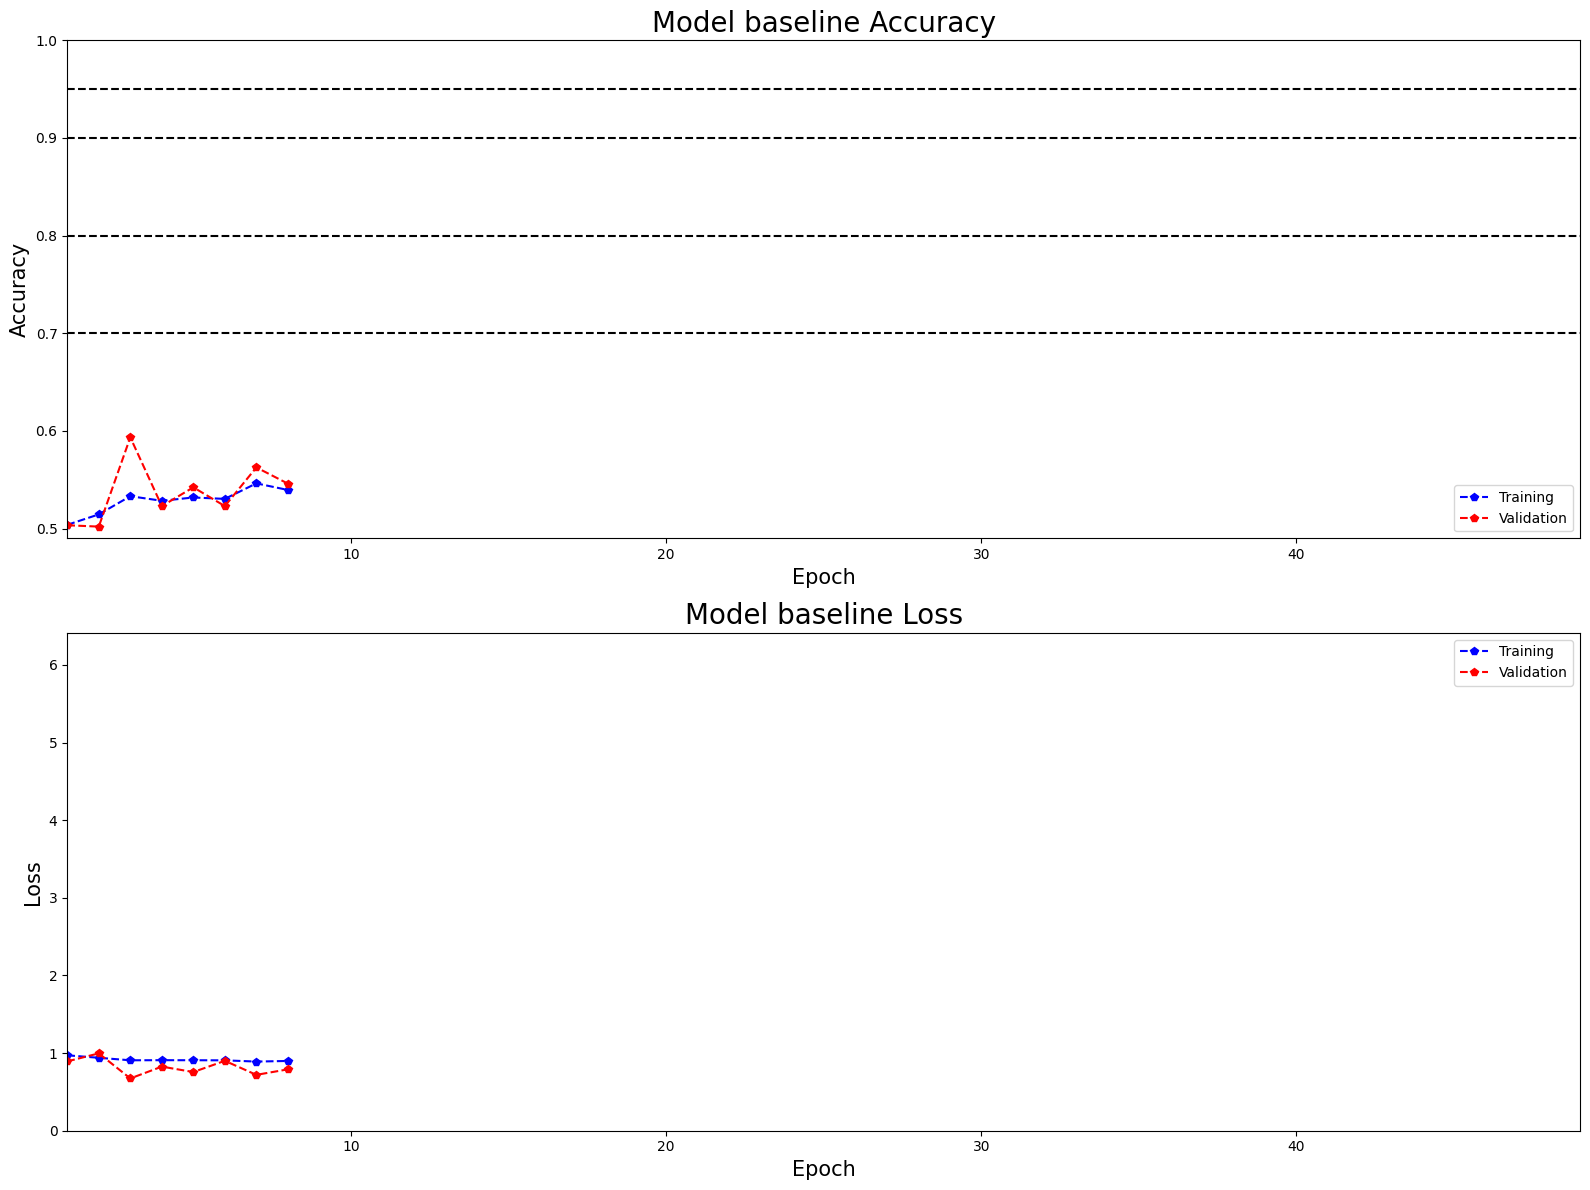

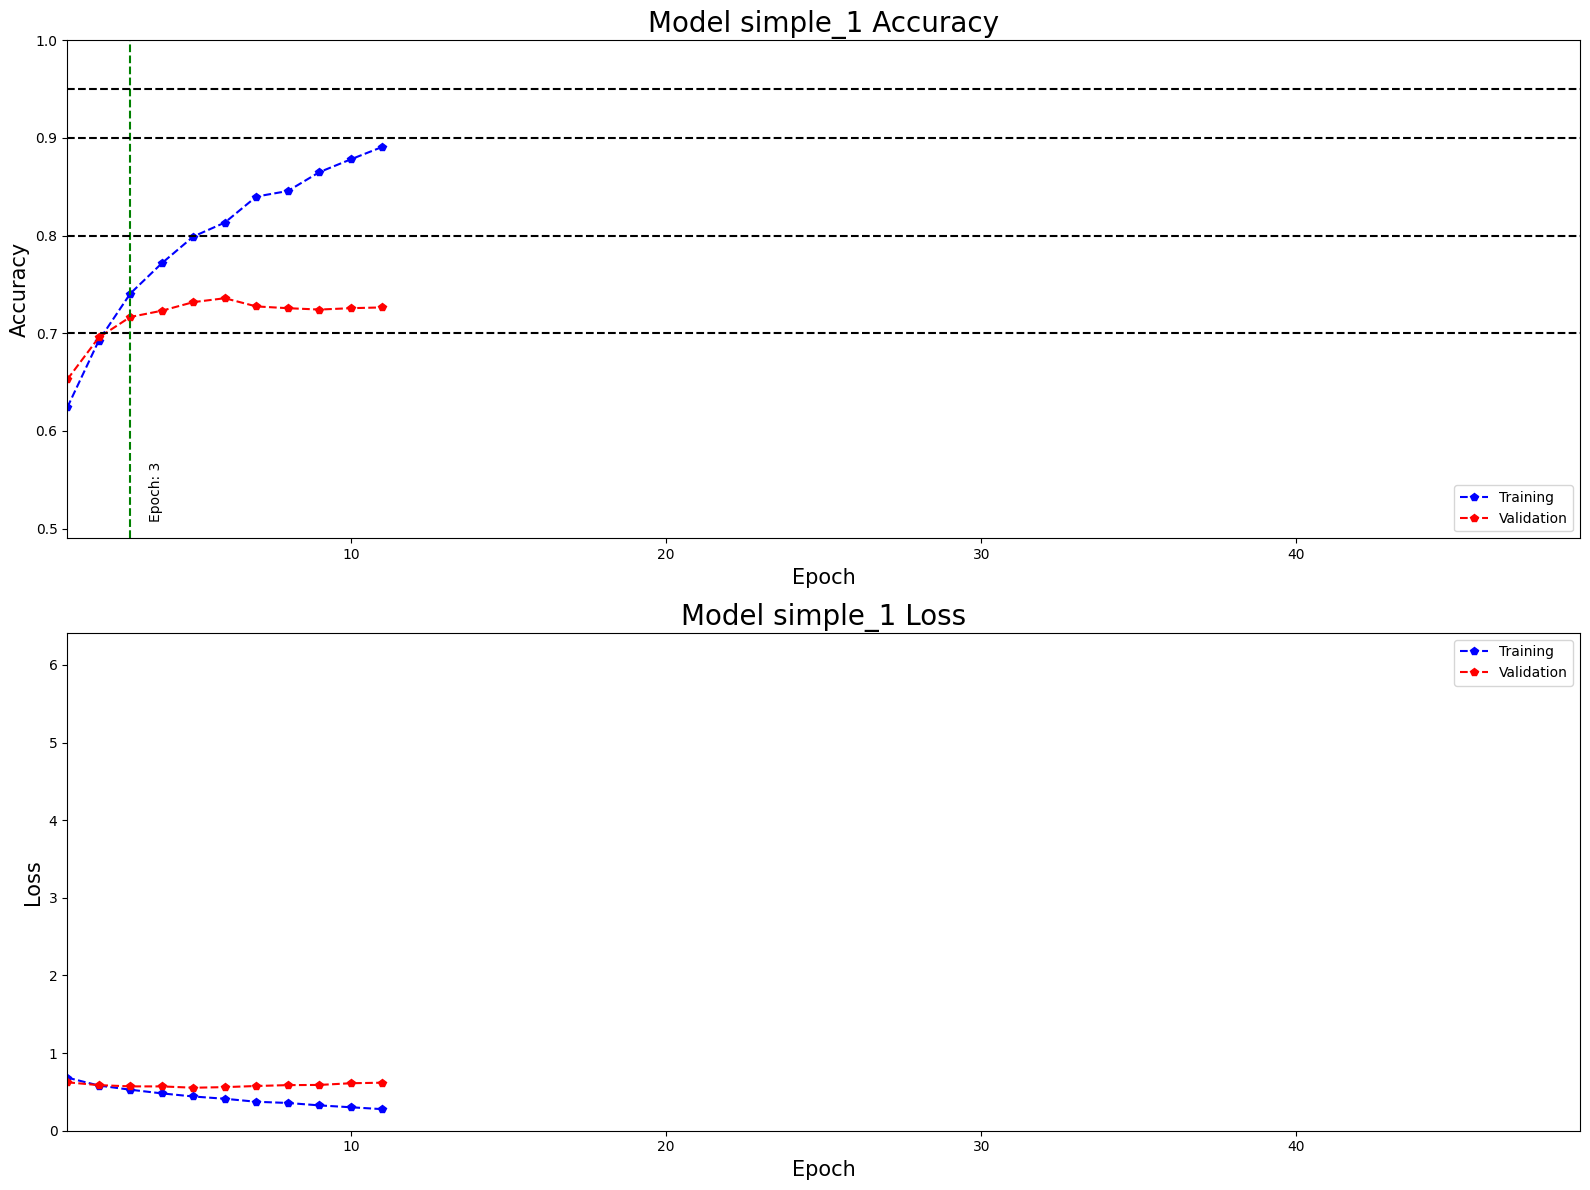

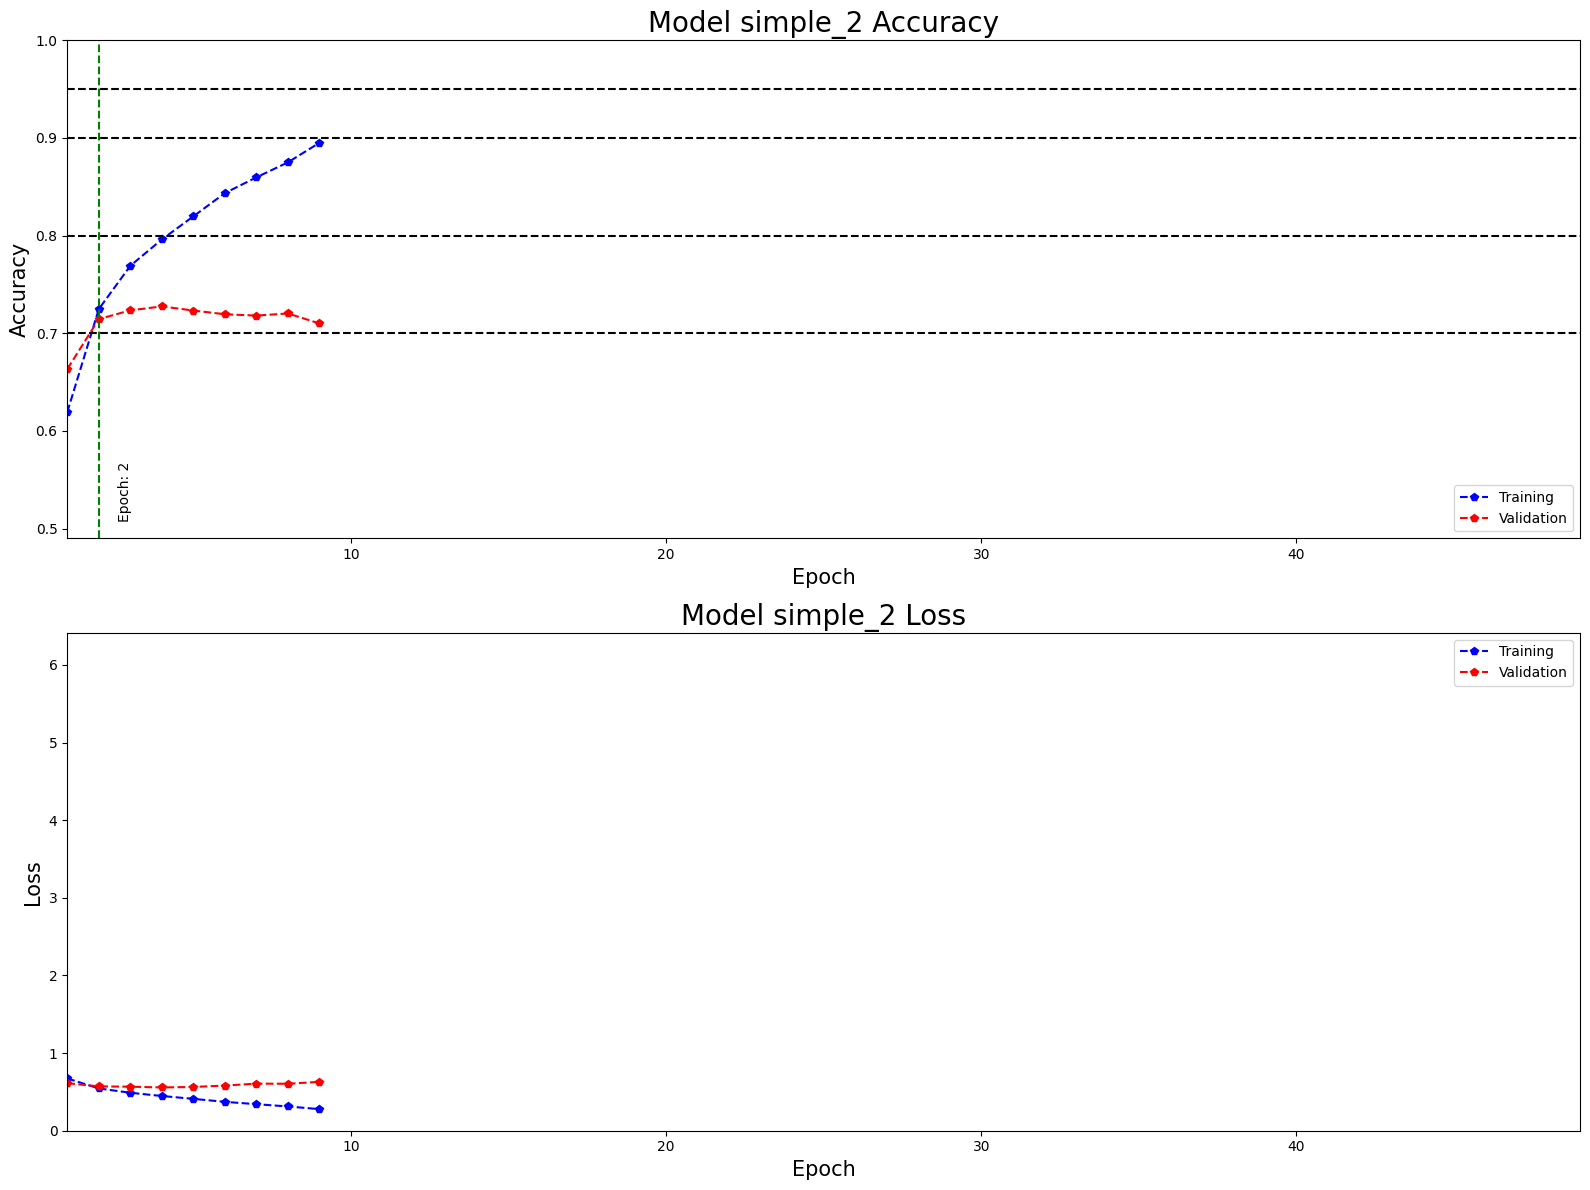

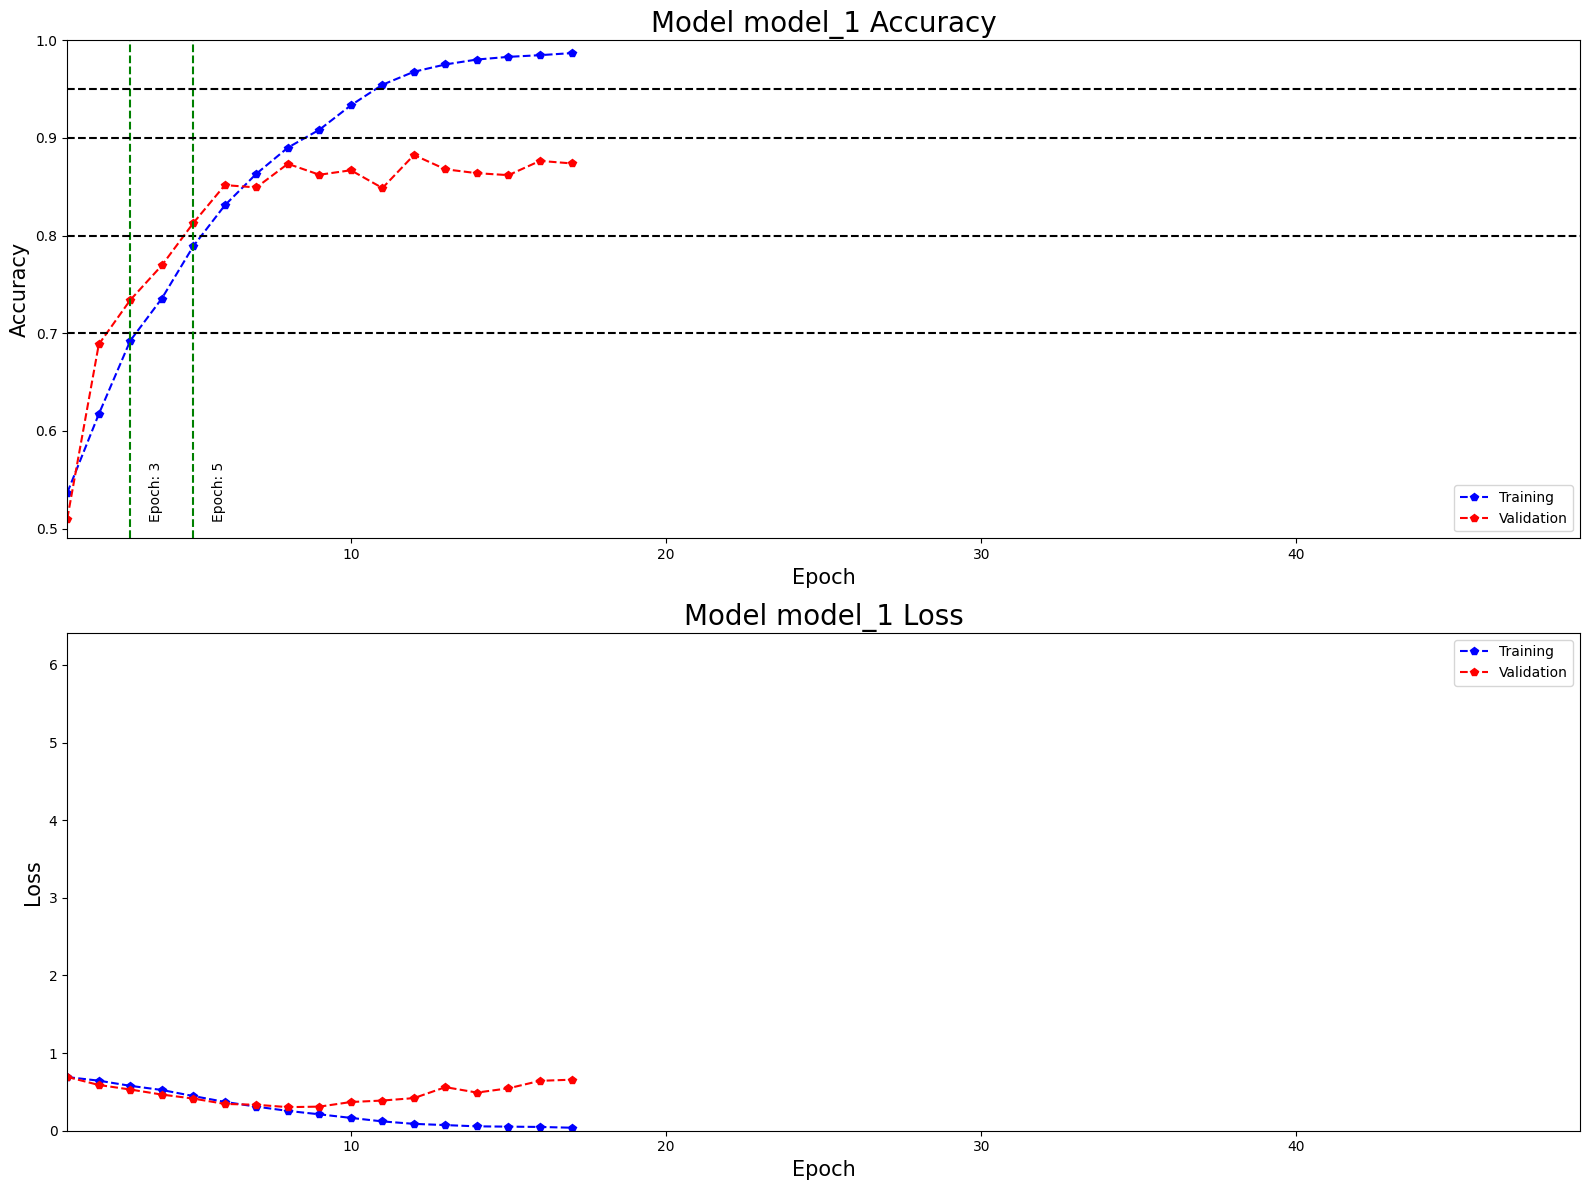

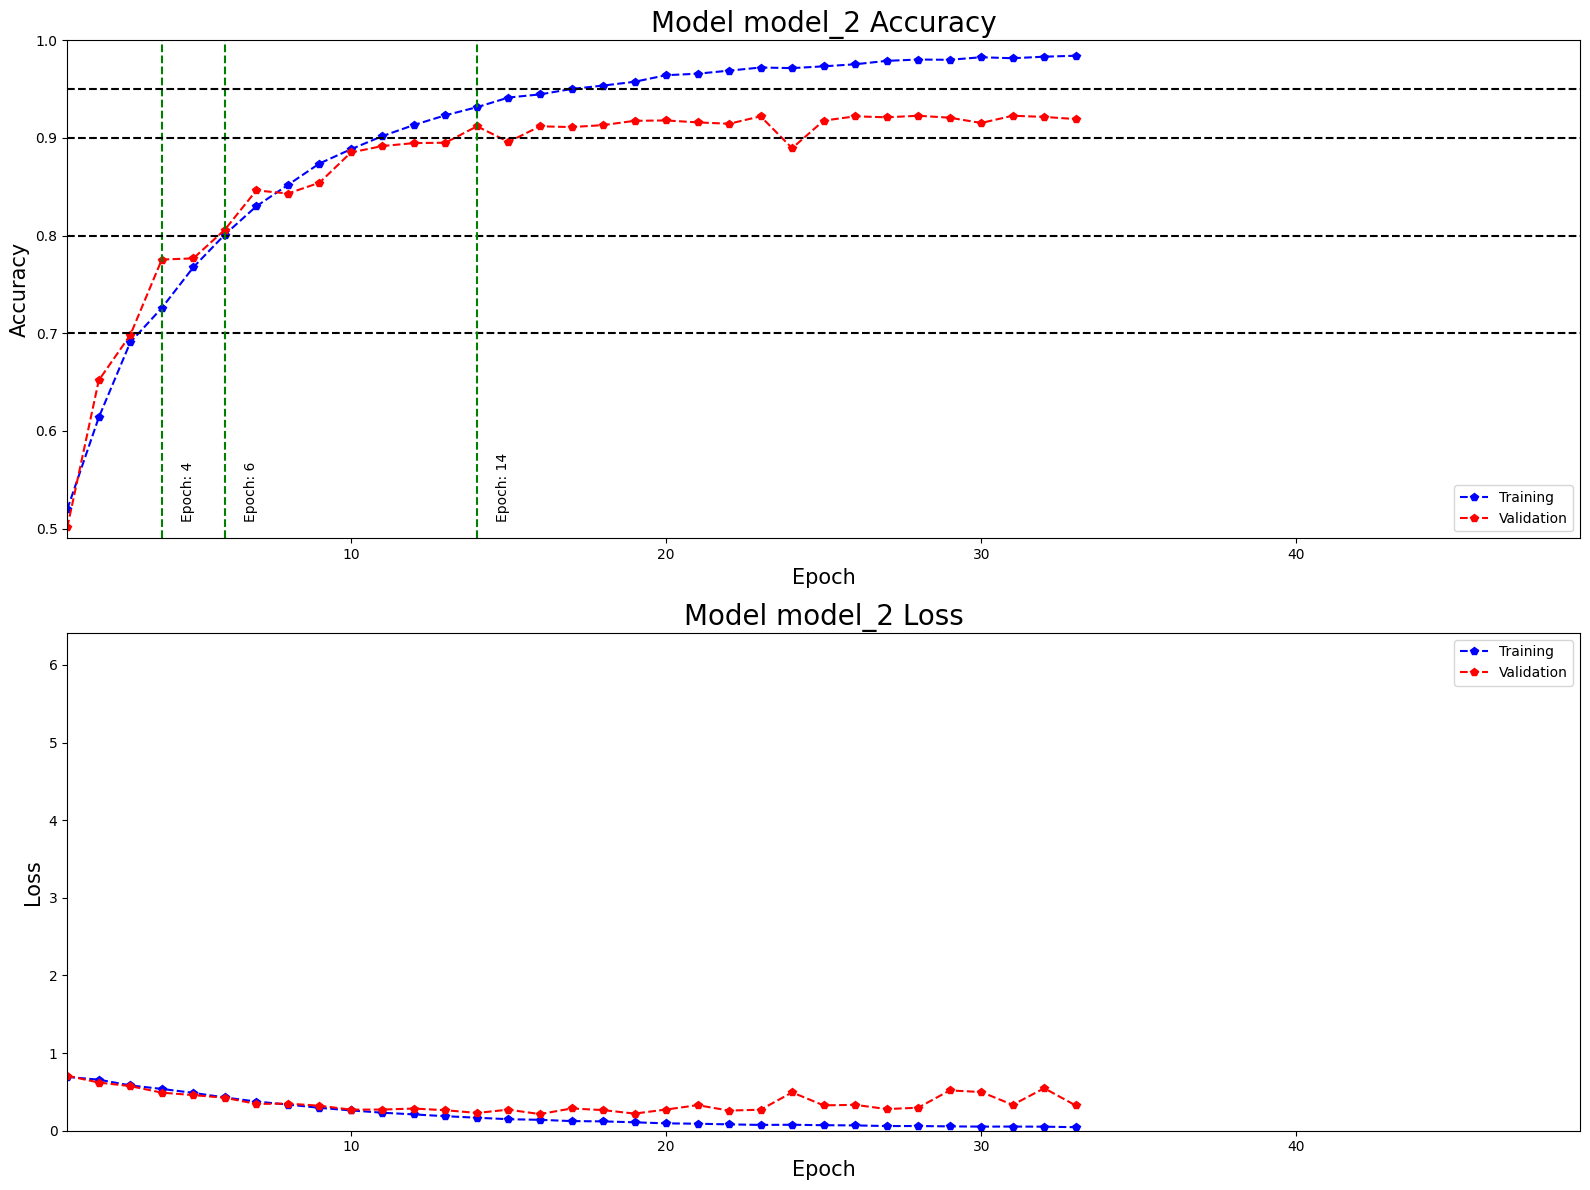

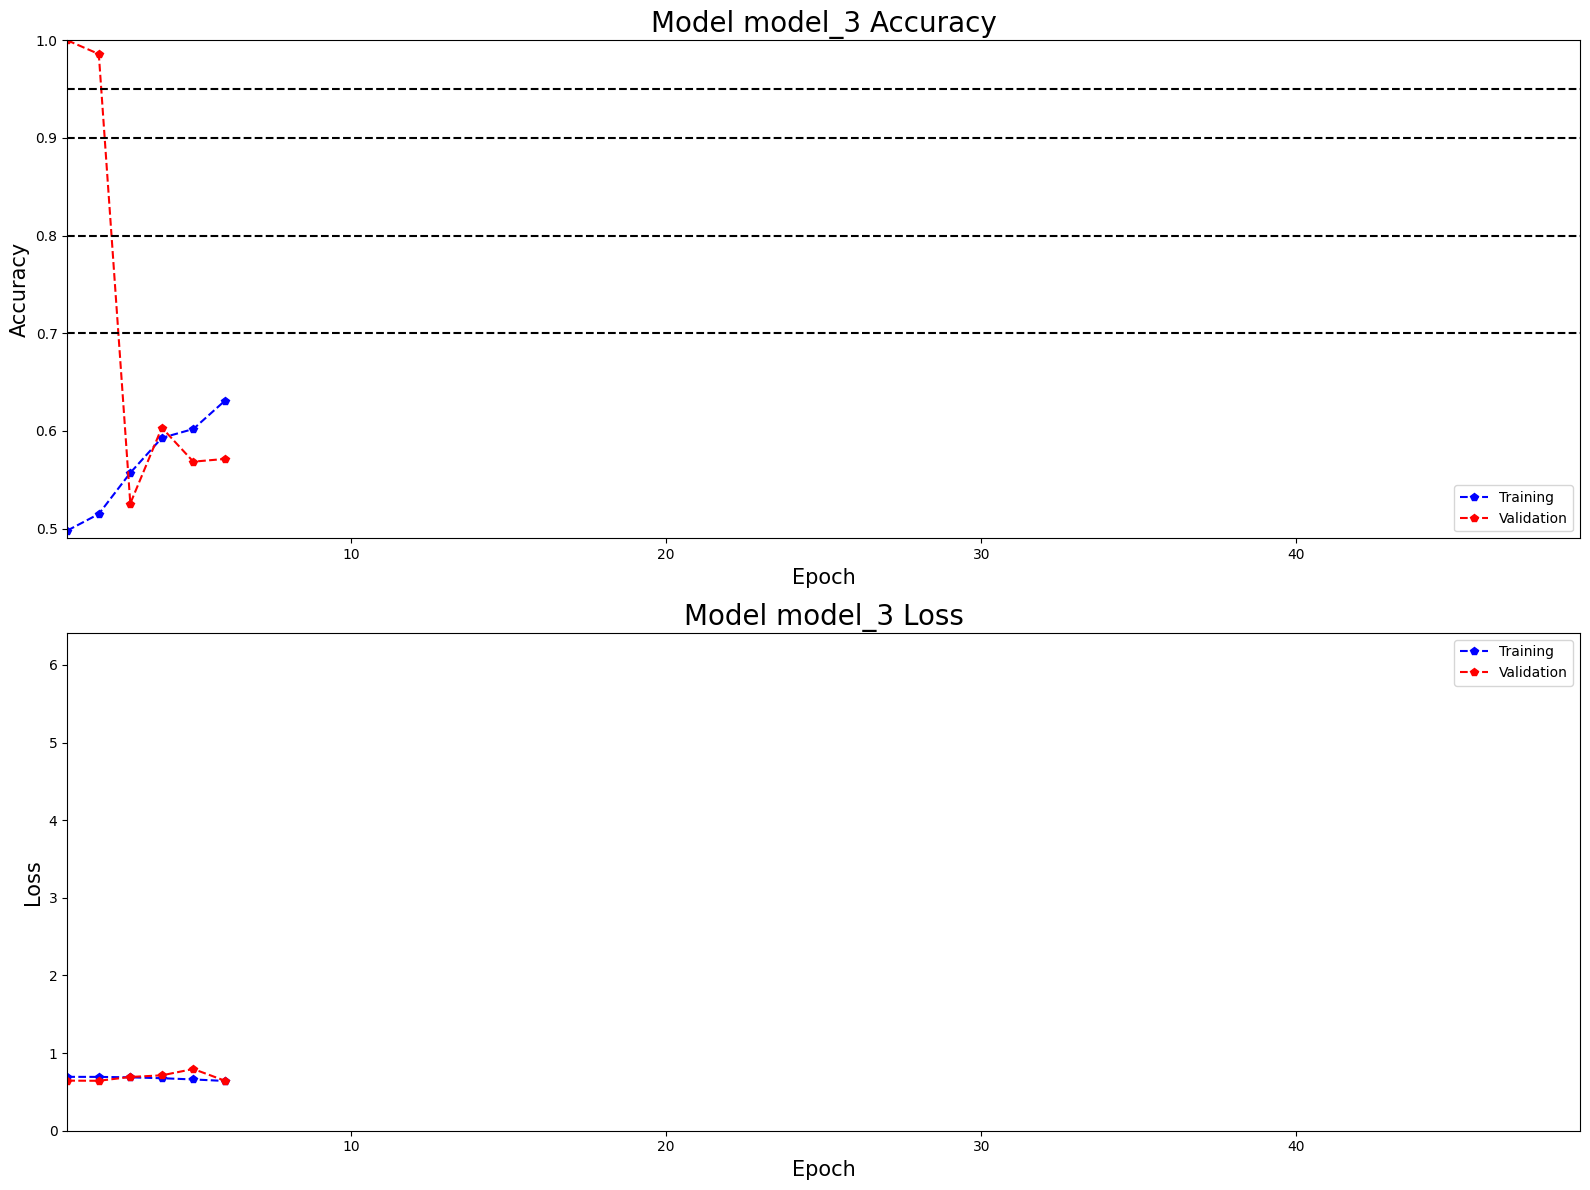

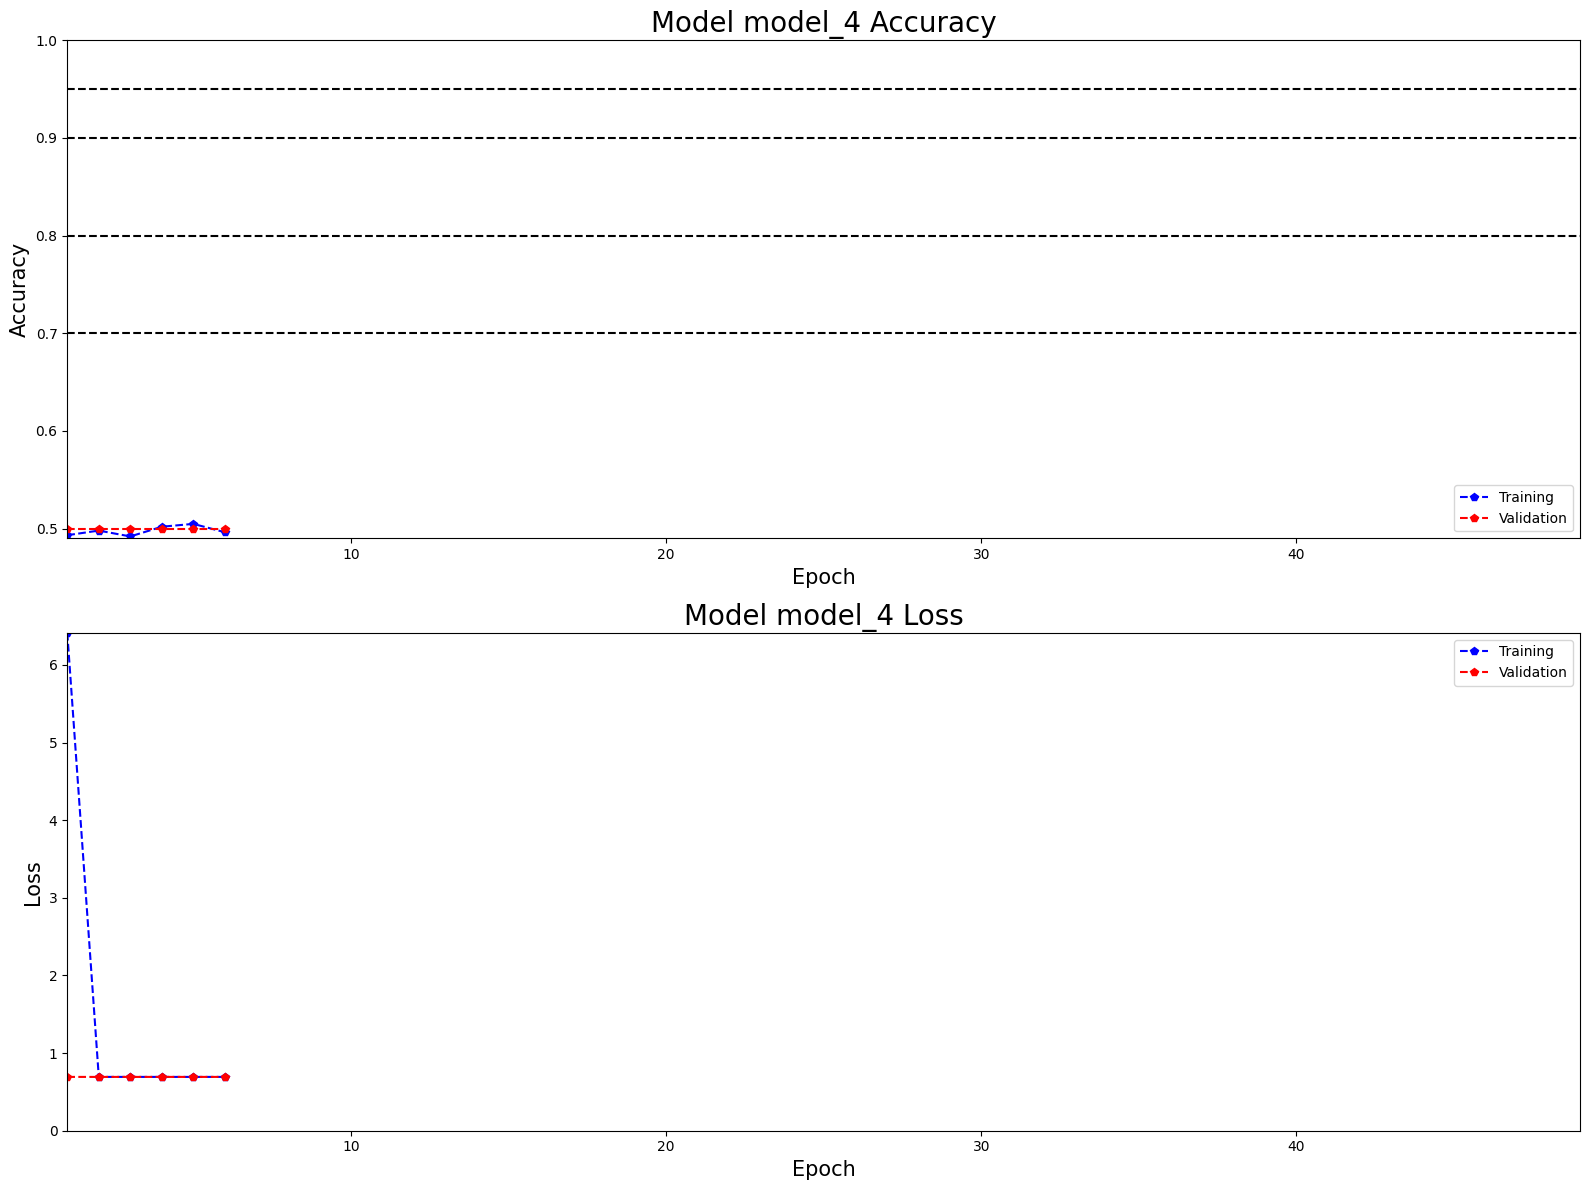

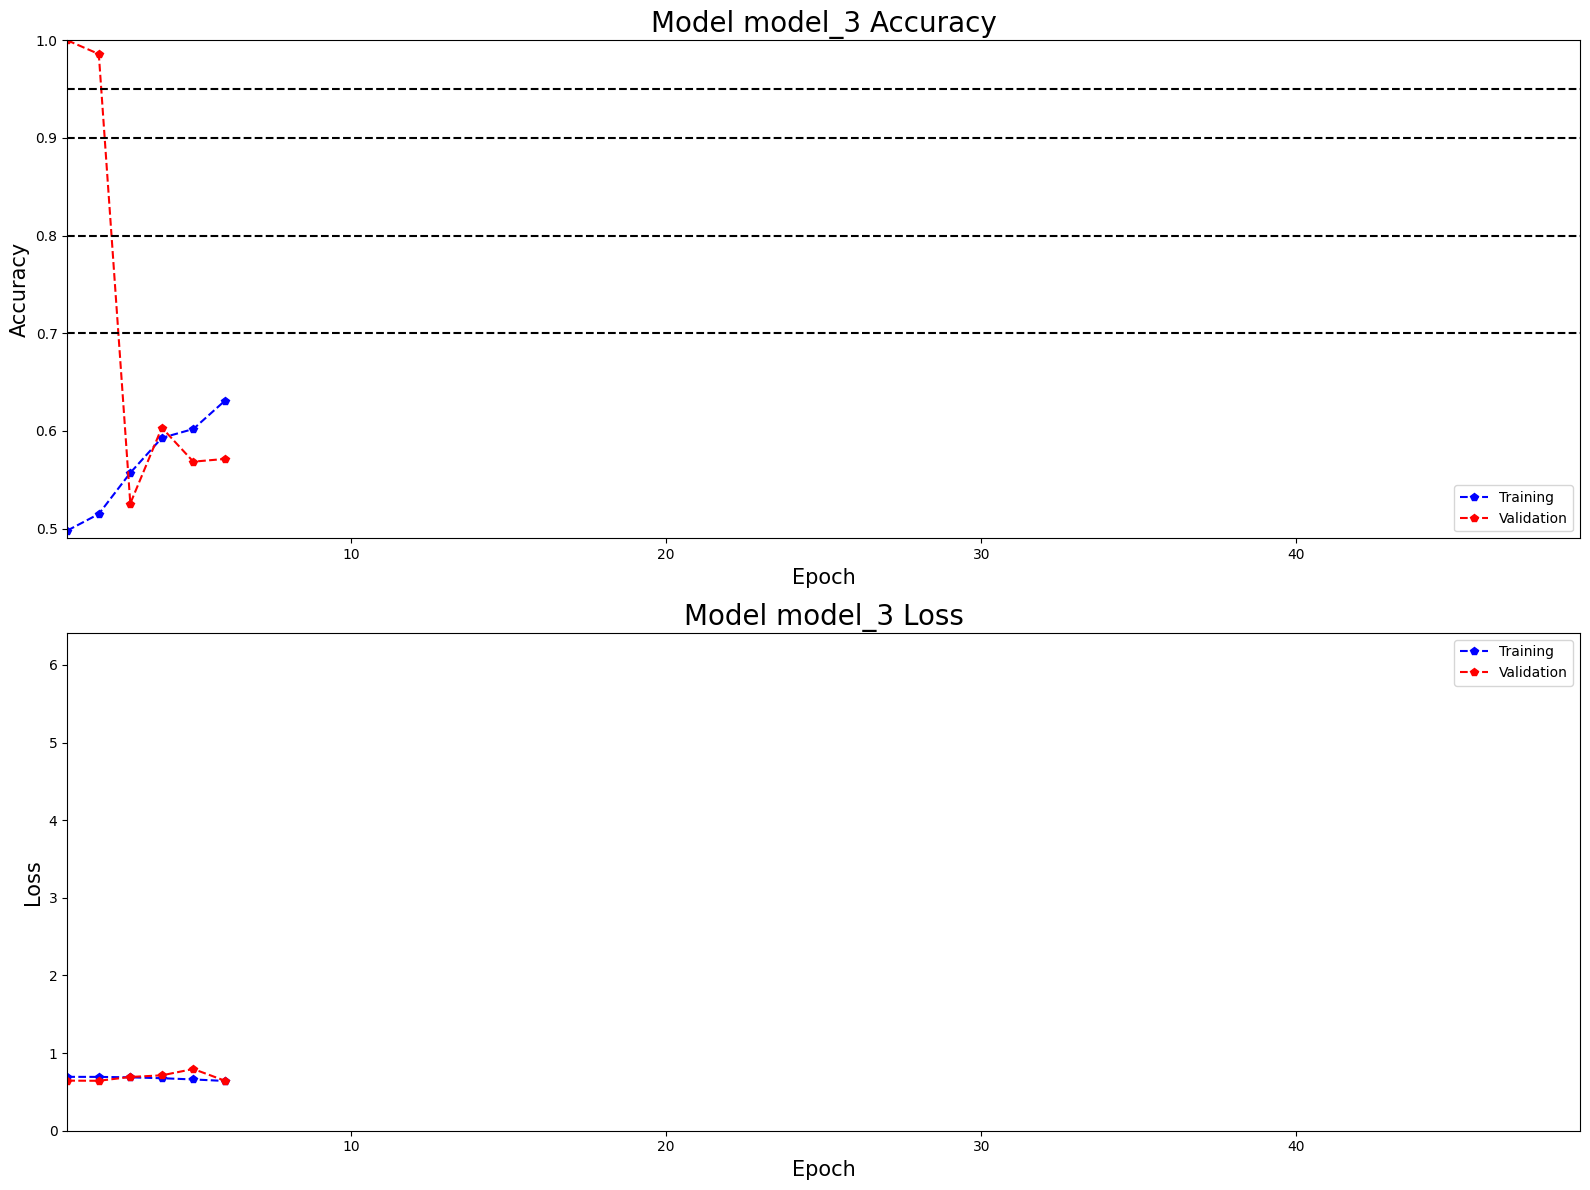

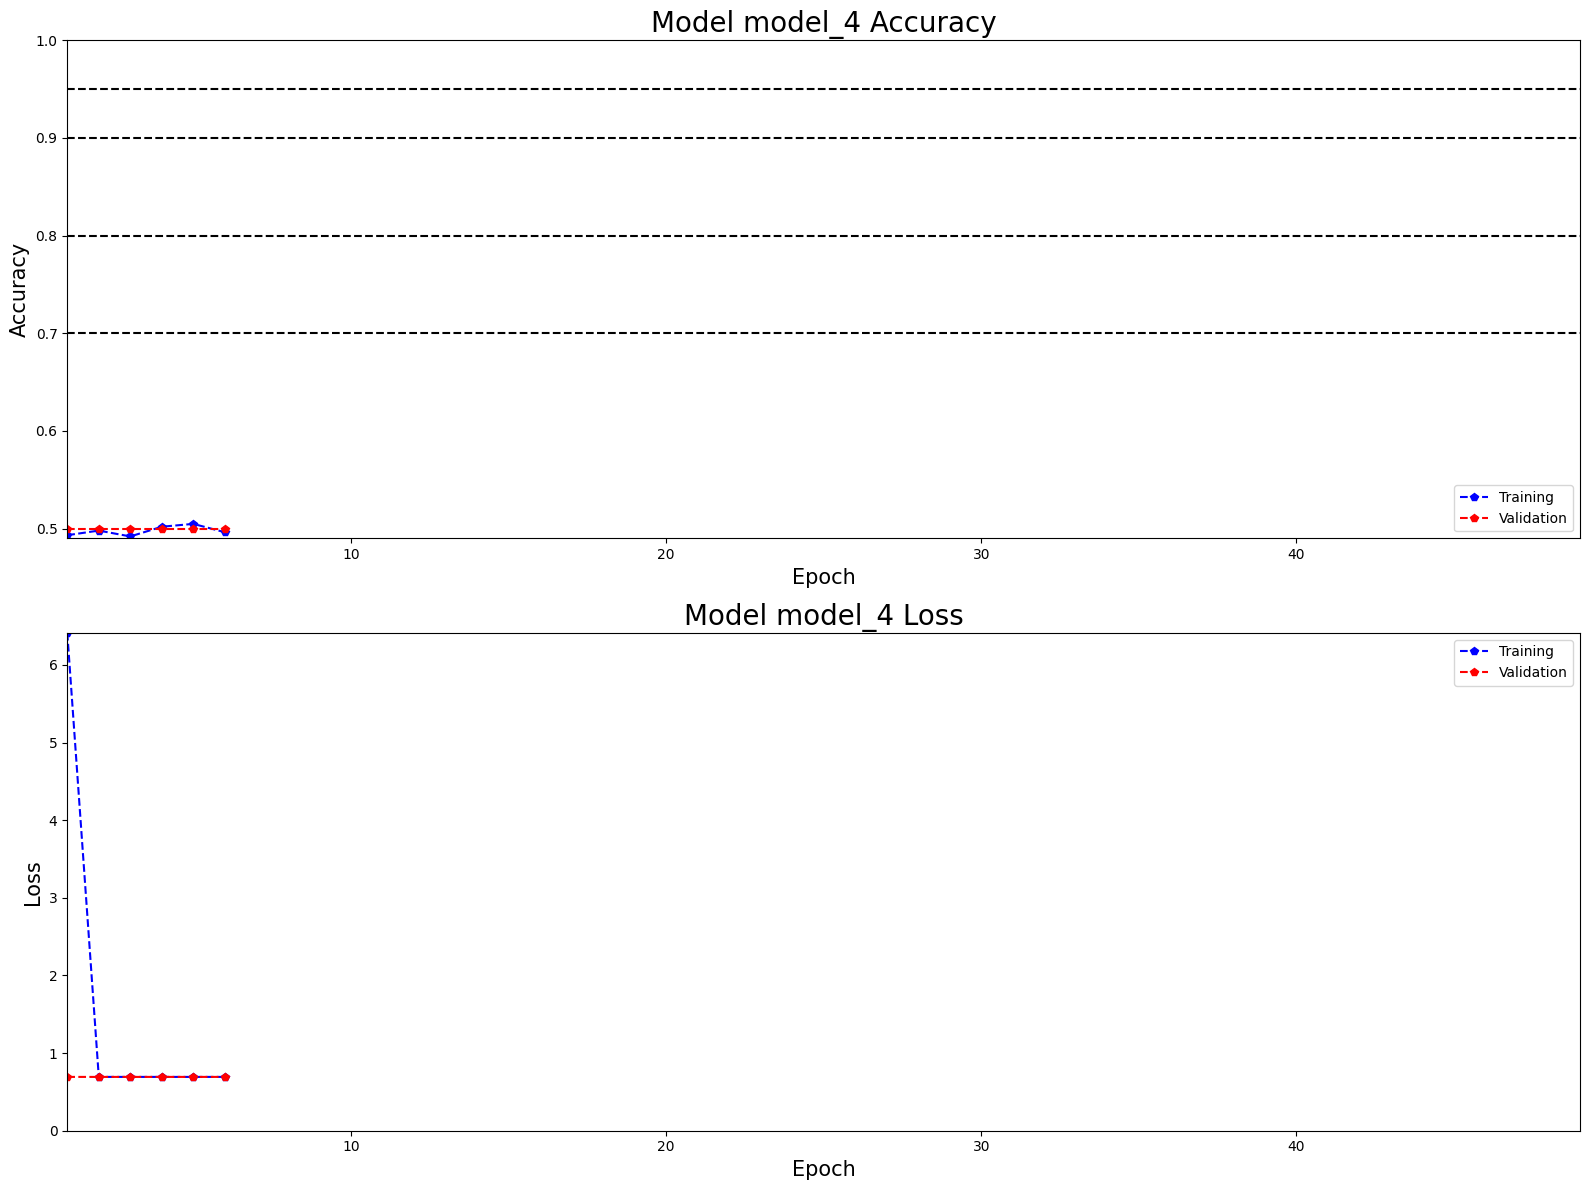

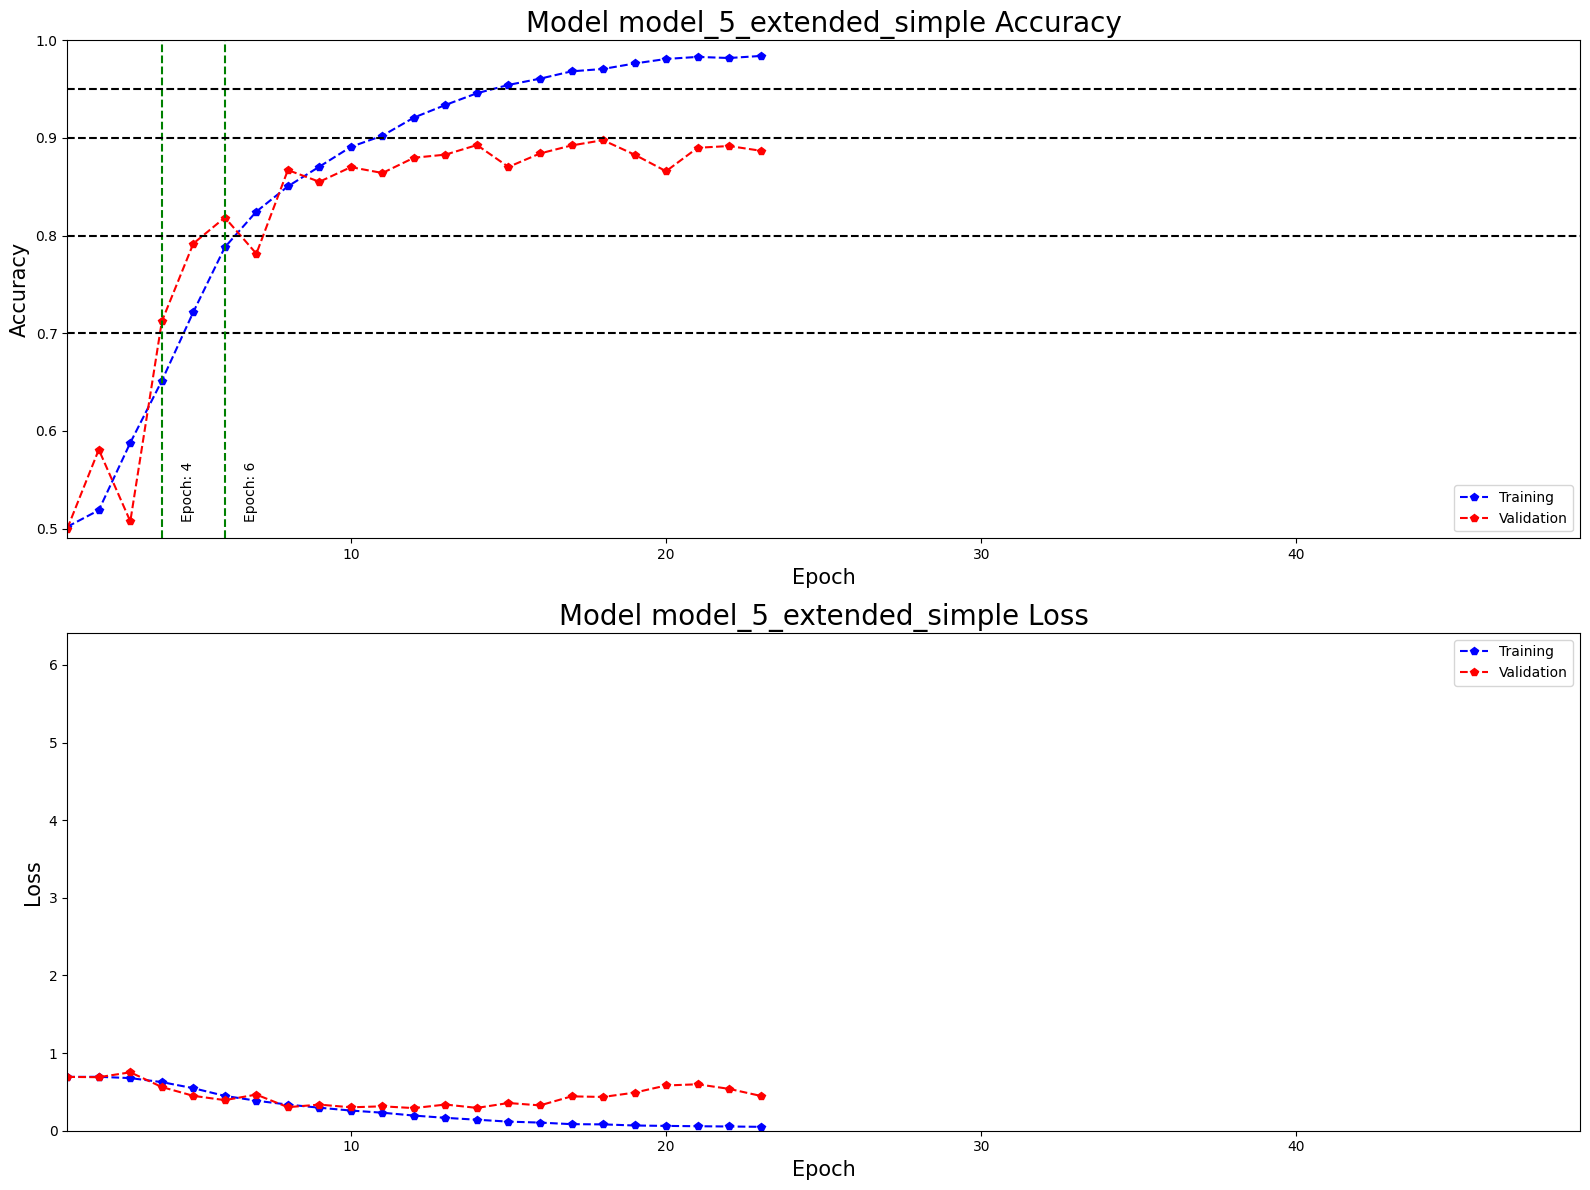

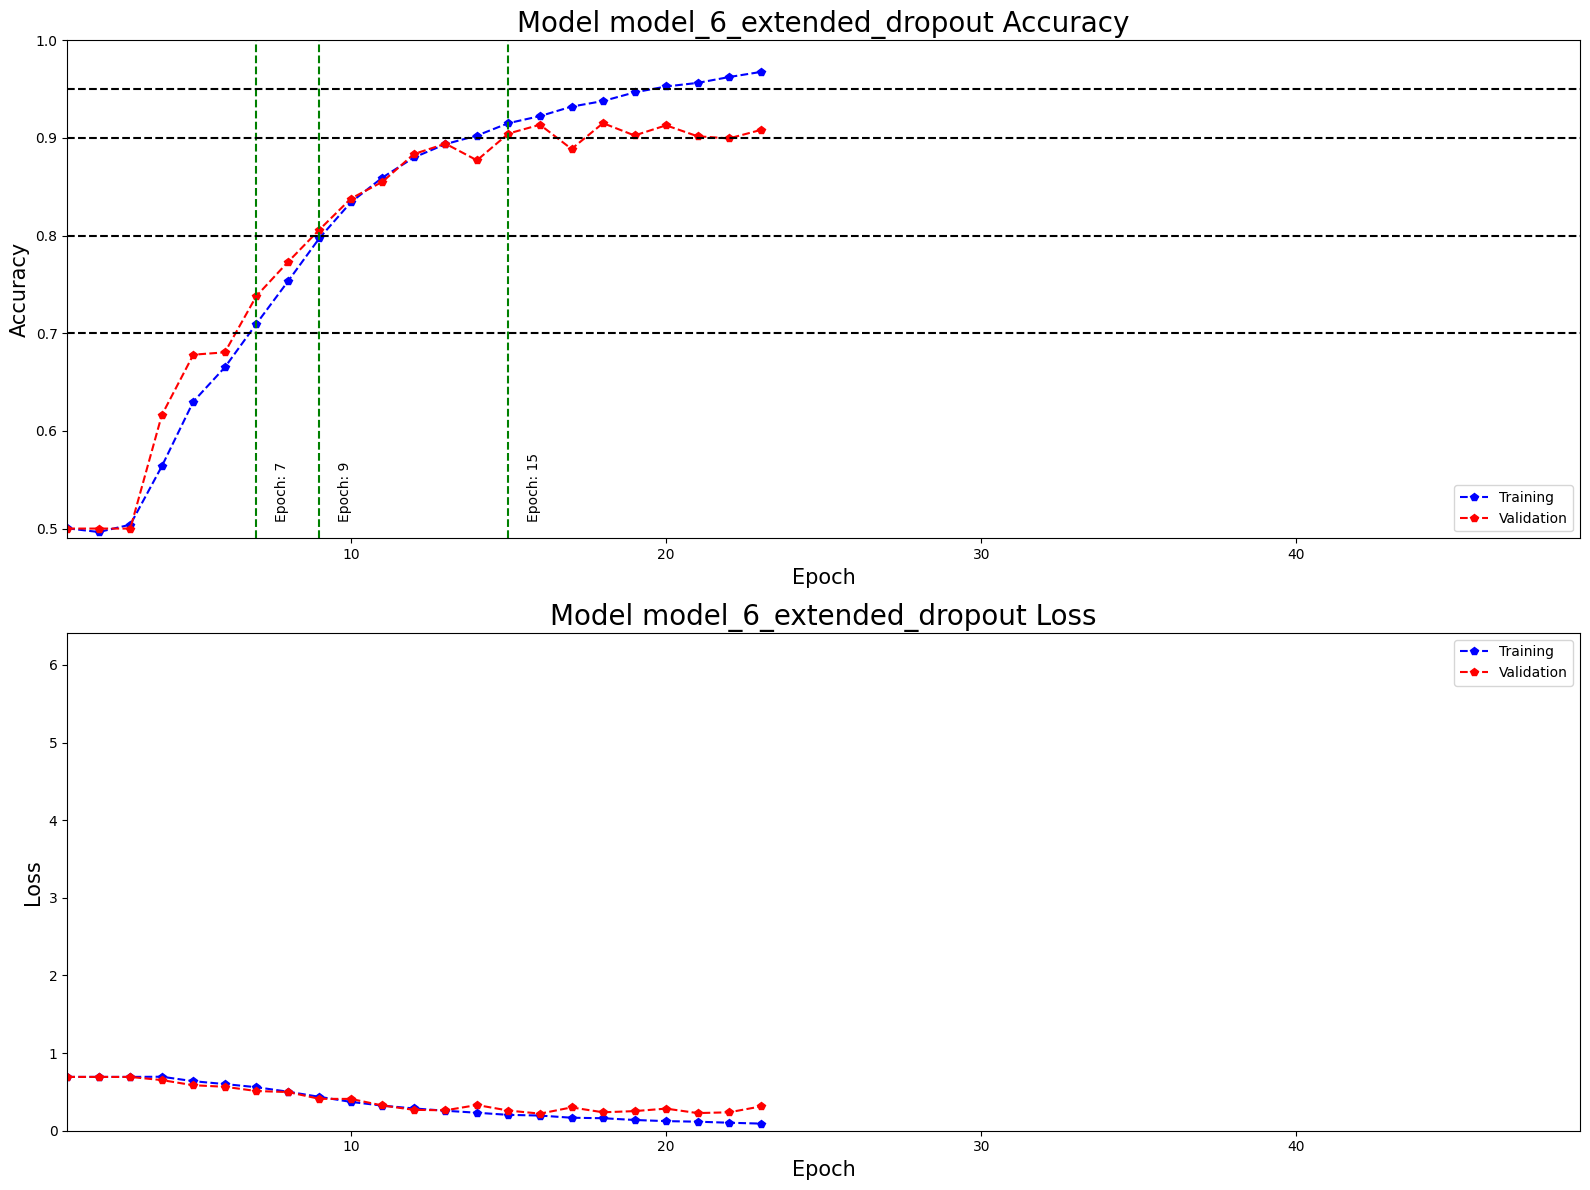

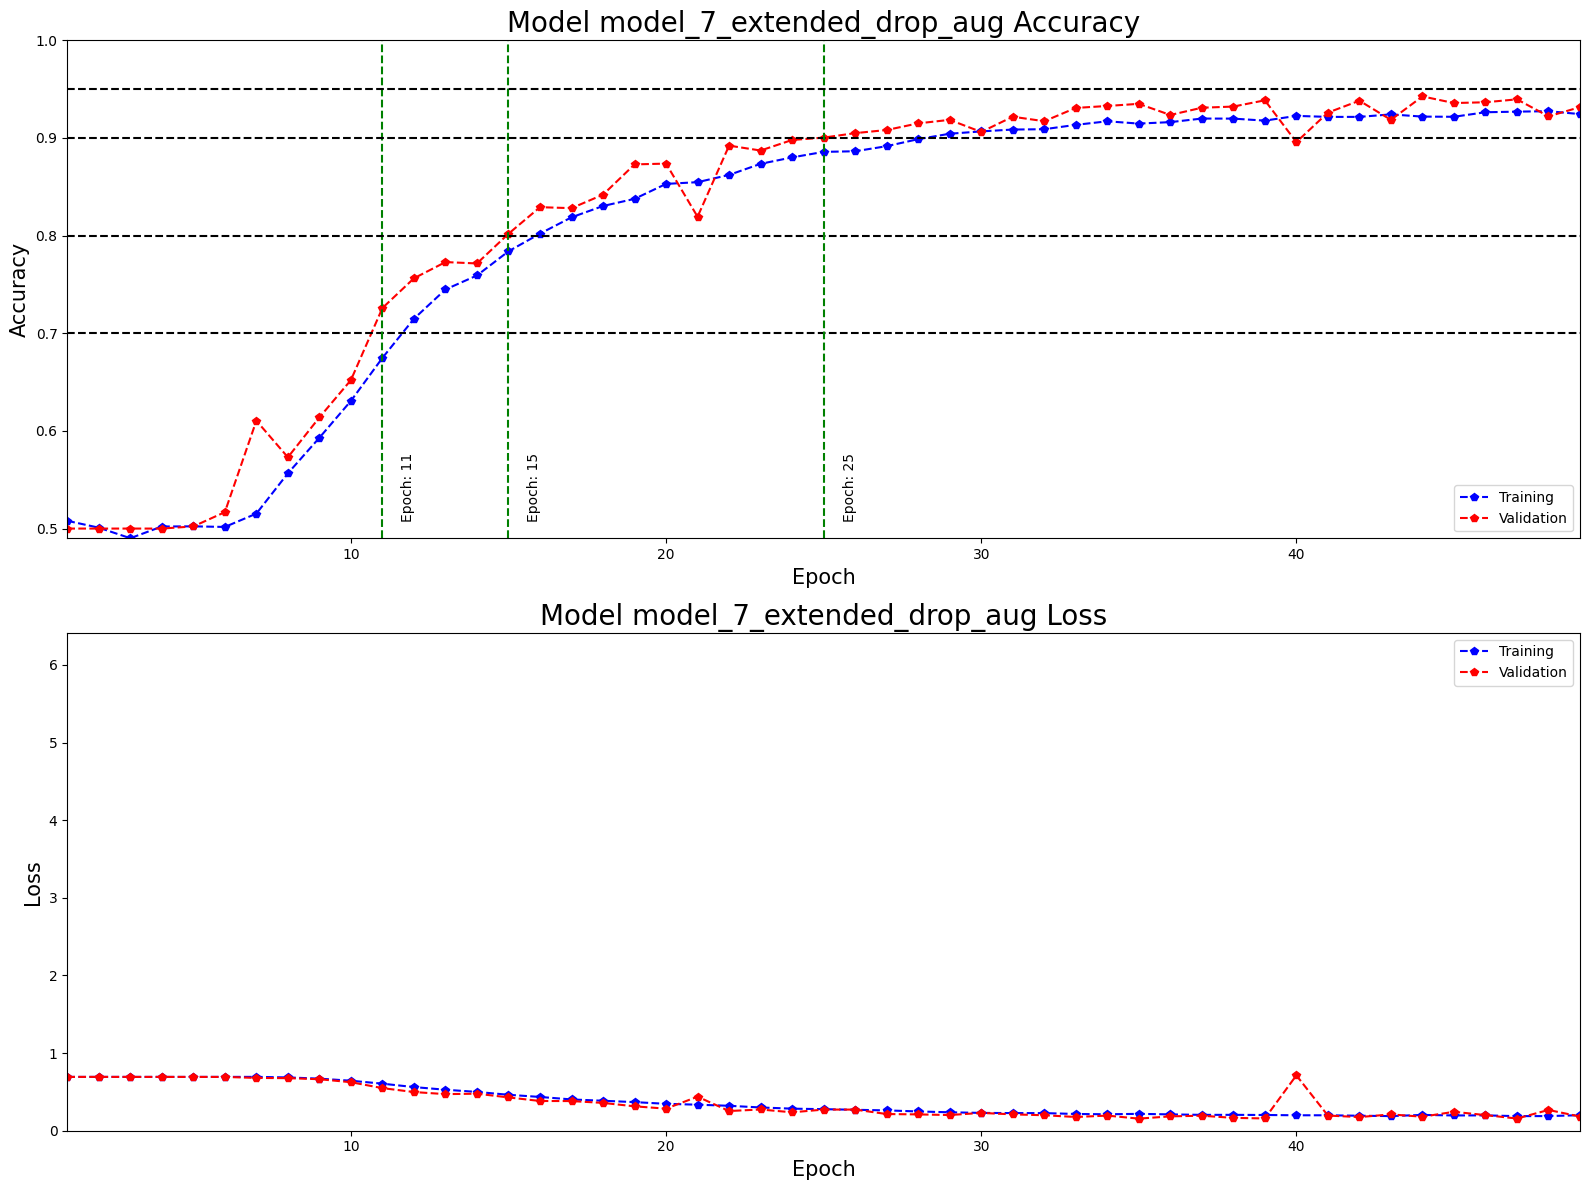

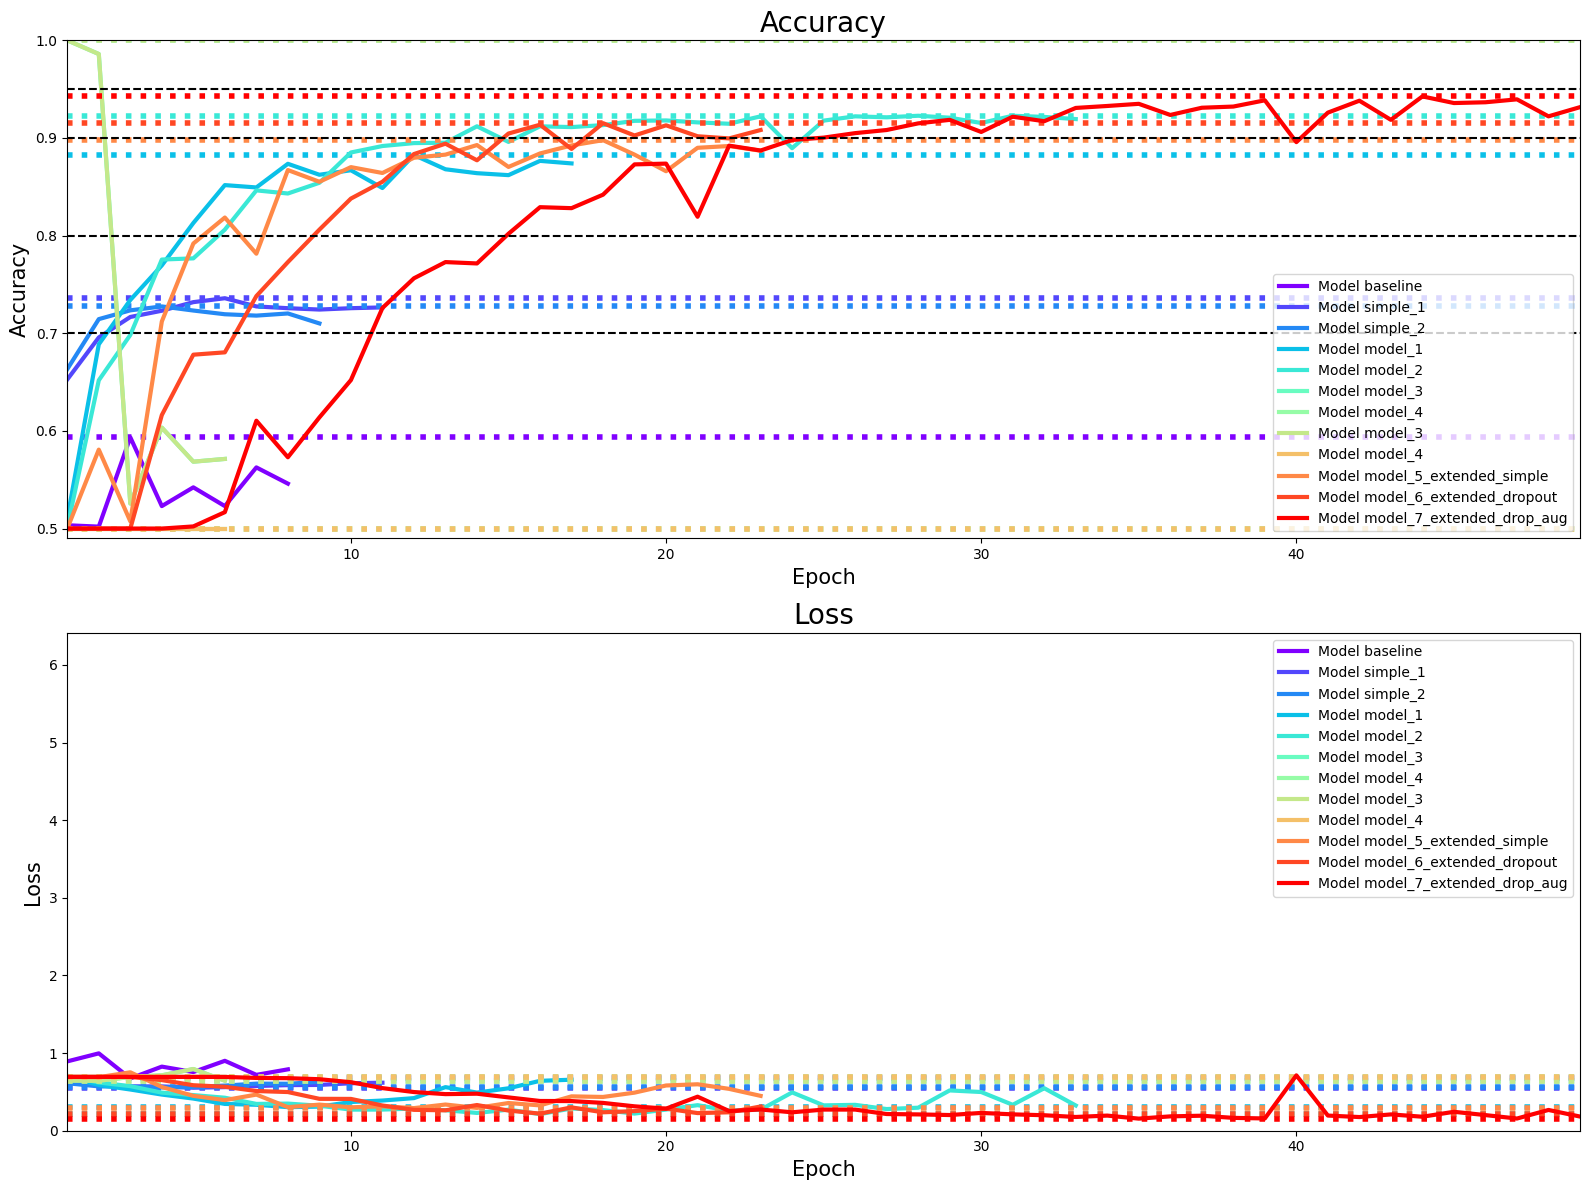

In [28]:
plot_models()

Przeprowadzone eksperymenty pokazują, że model bazowy nie nauczył się rozpoznawania klas. Nie wiem co się dzieje z modelem 3 i 4 nie mam za bardzo na to pomysłu. Modele simple_1 i simple_2 osiągnęły około 70% dokładności na zbiorze walidacyjnym, jednak dalszy wzrost różnicy między treningiem i walidacją wskazuje na dość szybkie przeuczenie. Wyraźnie lepsze są bardziej rozbudowane modele, szczególnie model_2, model_5 oraz model_6, których dokładność walidacyjna wynosiła około 90%. Najlepszy i najbardziej stabilny przebieg uczenia uzyskał model_7_extended_drop_aug. Zastosowanie dropout oraz augmentacji ograniczyło przeuczenie. Model 7 osiągnął powyżej 90% dokładności na zbiorze walidacyjnym, dlatego można uznać go za najlepszy spośród porównywanych wariantów. Ostateczną oceną powinno być sprawdzenie na zbiorze testowy.